In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

<h1>Feature Selection</h1>

In [ ]:
# loading the dataset
df = pd.read_csv('hamon_googlefit_medical_realistic.csv')

# defining the feature categories
identifier_cols = ['user_id', 'day_index']
target_col = 'cardiometabolic_risk_state'

# mapping lifestyle and biomarker features
lifestyle_features = [
    'steps', 'calories_burned', 'calories_consumed', 'move_minutes',
    'distance_km', 'sleep_hours', 'sleep_efficiency', 'water_intake_l'
]
biomarker_features = [
    'avg_heart_rate', 'resting_hr', 'bp_systolic', 'bp_diastolic',
    'fasting_glucose', 'spo2', 'hrv', 'bmi'
]

# keeping only the features we need, in df
df = df[identifier_cols + lifestyle_features + biomarker_features + [target_col]].copy()

display(df.head())
df.shape

,user_id,day_index,steps,calories_burned,calories_consumed,move_minutes,distance_km,sleep_hours,sleep_efficiency,water_intake_l,avg_heart_rate,resting_hr,bp_systolic,bp_diastolic,fasting_glucose,spo2,hrv,bmi,cardiometabolic_risk_state
0,1,1,10362,2038,2246,71,7.77,7.58540,0.93389,2.6,76,55,127.0,83.0,NaN,95,56,30.753735,2
1,1,2,11127,2337,2497,74,8.35,NaN,NaN,2.3,76,54,NaN,NaN,NaN,96,58,30.753735,2
2,1,3,11771,2098,2648,61,8.83,7.01264,0.91370,1.8,72,54,NaN,NaN,111.0,95,59,30.753735,2
3,1,4,12574,2135,2923,83,9.43,NaN,NaN,2.1,78,54,NaN,NaN,109.0,95,58,30.753735,2
4,1,5,10253,2058,2372,73,7.69,NaN,NaN,2.8,74,53,127.0,82.0,NaN,97,60,30.753735,2


(90000, 19)

<h1>Data Preprocessing</h1>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# SORTING & MISSING DATA HANDLING
df = df.sort_values(by=['user_id', 'day_index'])

user_counts = df['user_id'].value_counts()
valid_users = user_counts[user_counts >= 2].index
df = df[df['user_id'].isin(valid_users)].copy()

def impute_patient_data(x):
    return x.interpolate(method='linear', limit_direction='both').ffill().bfill()

df_imputed = df.copy()
cols_to_impute = lifestyle_features + biomarker_features
df_imputed[cols_to_impute] = df_imputed.groupby('user_id')[cols_to_impute].transform(impute_patient_data)

global_means = df_imputed[cols_to_impute].mean()
df_imputed[cols_to_impute] = df_imputed[cols_to_impute].fillna(global_means)


# using the 16 raw features
final_features_to_use = lifestyle_features + biomarker_features
print(f"Total features used: {len(final_features_to_use)}")


# SCALING AND PADDING
scaler = StandardScaler()
df_imputed[final_features_to_use] = scaler.fit_transform(df_imputed[final_features_to_use])

max_timesteps = df_imputed['day_index'].nunique()
num_features = len(final_features_to_use)
unique_users = df_imputed['user_id'].unique()
num_users = len(unique_users)

X_padded = np.full((num_users, max_timesteps, num_features), np.nan)
Y_target = np.zeros(num_users)

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}

for user_id, group in df_imputed.groupby('user_id'):
    idx = user_to_idx[user_id]
    user_features = group[final_features_to_use].values
    time_steps_available = user_features.shape[0]

    X_padded[idx, :time_steps_available, :] = user_features
    Y_target[idx] = group[target_col].iloc[0]

print(f"Preprocessing Complete")
print(f"Final 3D Time Series Shape (X): {X_padded.shape} -> [Patients, Timesteps, 16 Original Features]")
print(f"Final Target Array Shape (Y): {Y_target.shape}")

Total features used: 16
Preprocessing Complete
Final 3D Time Series Shape (X): (3000, 30, 16) -> [Patients, Timesteps, 16 Original Features]
Final Target Array Shape (Y): (3000,)


In [ ]:
# FINAL CATEGORY LISTS

final_lifestyle_features = lifestyle_features
final_biomarker_features = biomarker_features

print(f"Final Feature Breakdown")
print(f"Total Lifestyle Features ({len(final_lifestyle_features)}): {final_lifestyle_features}")
print(f"Total Biomarker Features ({len(final_biomarker_features)}): {final_biomarker_features}")

Final Feature Breakdown
Total Lifestyle Features (8): ['steps', 'calories_burned', 'calories_consumed', 'move_minutes', 'distance_km', 'sleep_hours', 'sleep_efficiency', 'water_intake_l']
Total Biomarker Features (8): ['avg_heart_rate', 'resting_hr', 'bp_systolic', 'bp_diastolic', 'fasting_glucose', 'spo2', 'hrv', 'bmi']


Visualizing the preprocessed data

In [ ]:
print(f"Total Patients (Samples): {X_padded.shape[0]}")
print(f"Max Timesteps (Days):     {X_padded.shape[1]}")
print(f"Features per Timestep:    {X_padded.shape[2]}")

# inspecting the first user in the array (Index 0)
user_idx = 0
actual_user_id = unique_users[user_idx]

print(f"Target Classification Label (Y): {Y_target[user_idx]}")

# Using our final feature list
user_0_df = pd.DataFrame(X_padded[user_idx], columns=final_features_to_use)

print("\nFirst 5 Days (Standardized & Imputed)")
# values must look like decimals (e.g., 0.5, -1.2) because they are standardized
print(user_0_df.head(5).to_string())

print("\nLast 5 Days (Checking for NaN Padding)")
# if any user had fewer than 30 days of data, we must see 'NaN' values here
print(user_0_df.tail(5).to_string())

Total Patients (Samples): 3000
Max Timesteps (Days):     30
Features per Timestep:    16
Target Classification Label (Y): 2.0

First 5 Days (Standardized & Imputed)
      steps  calories_burned  calories_consumed  move_minutes  distance_km  sleep_hours  sleep_efficiency  water_intake_l  avg_heart_rate  resting_hr  bp_systolic  bp_diastolic  fasting_glucose      spo2       hrv       bmi
0  0.939814         0.869063          -0.712623      1.066107     0.939296     0.483875          0.877350        0.496988       -0.067594   -0.767503    -0.430188     -0.317057         0.564982 -0.396937  0.131125  1.065257
1  1.131496         2.366133           0.117289      1.178336     1.133066     0.238625          0.768186       -0.002644       -0.067594   -0.848700    -0.430188     -0.340948         0.564982  0.458224  0.231541  1.065257
2  1.292859         1.169479           0.616559      0.692012     1.293427    -0.006625          0.659022       -0.835365       -0.410237   -0.848700    -0.430188 

<h1> 9 Days Data to Predict 21 Days Data</h1>

<h3>Time Series Forest Regressor</h3>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

# 9 Days Observed to predict next 21 days
OBSERVED_DAYS = 9
PREDICT_DAYS = 21

num_biomarker_features = len(final_biomarker_features)
num_all_features = len(final_features_to_use)

# Finding exact column index numbers in the 3D array
biomarker_indices = [final_features_to_use.index(b) for b in final_biomarker_features]

# Slicing the 3D Tensor for Forecasting
valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
print(f"Valid users with at least {OBSERVED_DAYS + PREDICT_DAYS} days of data: {len(X_valid)}")

X_input = X_valid[:, :OBSERVED_DAYS, :] # First 9 days (context)

# Target 1: All 16 Features
Y_future_all = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :]
# Target 2: Only 8 Biomarkers
Y_future_bio = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :][:, :, biomarker_indices]

# Flattening
X_input_flat = X_input.reshape(X_input.shape[0], -1)
Y_future_all_flat = Y_future_all.reshape(Y_future_all.shape[0], -1)
Y_future_bio_flat = Y_future_bio.reshape(Y_future_bio.shape[0], -1)

# Splitting identically (using random_state=42 ensures the exact same patients go to the test set)
X_train, X_test, y_train_all, y_test_all = train_test_split(X_input_flat, Y_future_all_flat, test_size=0.2, random_state=42)
_, _, y_train_bio, y_test_bio = train_test_split(X_input_flat, Y_future_bio_flat, test_size=0.2, random_state=42)

# HYPERPARAMETER TUNING (GridSearchCV Setup)
param_grid = {
    'n_estimators': [150],
    'max_depth': [10]
}
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# TRACK 1: PREDICTING ALL 16 FEATURES
print("\nTraining Track 1: ALL 16 Features")
grid_search_all = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=2)
grid_search_all.fit(X_train, y_train_all)
best_rf_all = grid_search_all.best_estimator_
y_pred_all = best_rf_all.predict(X_test)


# TRACK 2: PREDICTING 8 BIOMARKERS ONLY
print("Training Track 2: 8 Biomarkers Only")
grid_search_bio = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=2)
grid_search_bio.fit(X_train, y_train_bio)
best_rf_bio = grid_search_bio.best_estimator_
y_pred_bio = best_rf_bio.predict(X_test)


# METRICS EVALUATION
def print_forecasting_metrics(y_true, y_pred, track_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    sigma_y = np.std(y_true)
    nrmse = rmse / sigma_y if sigma_y != 0 else 0

    print(f"\n{track_name} Performance:")
    print(f"MSE:   {mse:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"NRMSE: {nrmse:.4f} (Goal: < 1.0)")
    print(f"R²:    {r2:.4f} (Goal: > 0.2)")
    return r2

print("DUAL-TEST RESULTS (Random Forest Baseline)")

r2_all = print_forecasting_metrics(y_test_all, y_pred_all, "Track 1 [All 16 Features]")
r2_bio = print_forecasting_metrics(y_test_bio, y_pred_bio, "Track 2 [8 Biomarkers Only]")

if r2_all > r2_bio:
    print("Conclusion: Forecasting ALL features yields a more stable trajectory.")
else:
    print("Conclusion: Isolating biomarkers yields a cleaner, more accurate forecast.")

Valid users with at least 30 days of data: 3000

Training Track 1: ALL 16 Features
Training Track 2: 8 Biomarkers Only
DUAL-TEST RESULTS (Random Forest Baseline)

Track 1 [All 16 Features] Performance:
MSE:   0.7253
RMSE:  0.8516
MAE:   0.6462
NRMSE: 0.8480 (Goal: < 1.0)
R²:    0.2745 (Goal: > 0.2)

Track 2 [8 Biomarkers Only] Performance:
MSE:   0.5179
RMSE:  0.7196
MAE:   0.5154
NRMSE: 0.7139 (Goal: < 1.0)
R²:    0.4887 (Goal: > 0.2)
Conclusion: Isolating biomarkers yields a cleaner, more accurate forecast.


Comparing the resuls with the Naive Baseline Model (LOCF)

In [ ]:
# Reshaping X_test back to 3D to grab the final observed day
X_test_3d = X_test.reshape(X_test.shape[0], OBSERVED_DAYS, num_all_features)

# Grabbing the very last observed day (Day 9) for all test patients
last_observed_all = X_test_3d[:, -1, :]

# Filter down to ONLY the biomarkers for Track 2
last_observed_bio = last_observed_all[:, biomarker_indices]

# Repeat Day 9's values 21 times to guess Days 10 through 30
naive_y_pred_all = np.tile(last_observed_all, (1, PREDICT_DAYS))
naive_y_pred_bio = np.tile(last_observed_bio, (1, PREDICT_DAYS))

# Evaluate the Naive Baseline using our helper function
print("\nTRACK 1 NAIVE: ALL 16 FEATURES")
naive_r2_all = print_forecasting_metrics(y_test_all, naive_y_pred_all, "Naive Baseline [All 16 Features]")

print("\nTRACK 2 NAIVE: 8 BIOMARKERS ONLY")
naive_r2_bio = print_forecasting_metrics(y_test_bio, naive_y_pred_bio, "Naive Baseline [8 Biomarkers Only]")

# Final Comparison: Random Forest vs Naive

print("MODEL COMPARISON: Random Forest vs Naive Baseline\n")

print(f"Track 1 (All 16 Features): RF R² = {r2_all[0] if isinstance(r2_all, list) else r2_all:.4f}  |  Naive R² = {naive_r2_all:.4f}")
print(f"Track 2 (8 Biomarkers):    RF R² = {r2_bio[0] if isinstance(r2_bio, list) else r2_bio:.4f}  |  Naive R² = {naive_r2_bio:.4f}")

if (r2_all > naive_r2_all) and (r2_bio > naive_r2_bio):
    print("\nThe Random Forest beat the naive baseline in both tracks.")
else:
    print("\nThe Naive Baseline won. Time-blind models struggle to beat simple extrapolation.")


TRACK 1 NAIVE: ALL 16 FEATURES

Naive Baseline [All 16 Features] Performance:
MSE:   1.2413
RMSE:  1.1141
MAE:   0.7911
NRMSE: 1.1095 (Goal: < 1.0)
R²:    -0.2480 (Goal: > 0.2)

TRACK 2 NAIVE: 8 BIOMARKERS ONLY

Naive Baseline [8 Biomarkers Only] Performance:
MSE:   0.7917
RMSE:  0.8898
MAE:   0.5657
NRMSE: 0.8827 (Goal: < 1.0)
R²:    0.2161 (Goal: > 0.2)
MODEL COMPARISON: Random Forest vs Naive Baseline

Track 1 (All 16 Features): RF R² = 0.2745  |  Naive R² = -0.2480
Track 2 (8 Biomarkers):    RF R² = 0.4887  |  Naive R² = 0.2161

The Random Forest beat the naive baseline in both tracks.


<h1>LSTM Model</h1>

1. Standard LSTM

Predicting 16 biomarkers

TRACK 1: PREDICTING ALL 16 FEATURES

Starting 5-Fold Cross Validation (16 Features)
Fold 1 MAE: 0.5973
Fold 2 MAE: 0.6995
Fold 3 MAE: 0.7089
Fold 4 MAE: 0.7047
Fold 5 MAE: 0.6907
Average Validation MAE: 0.6802


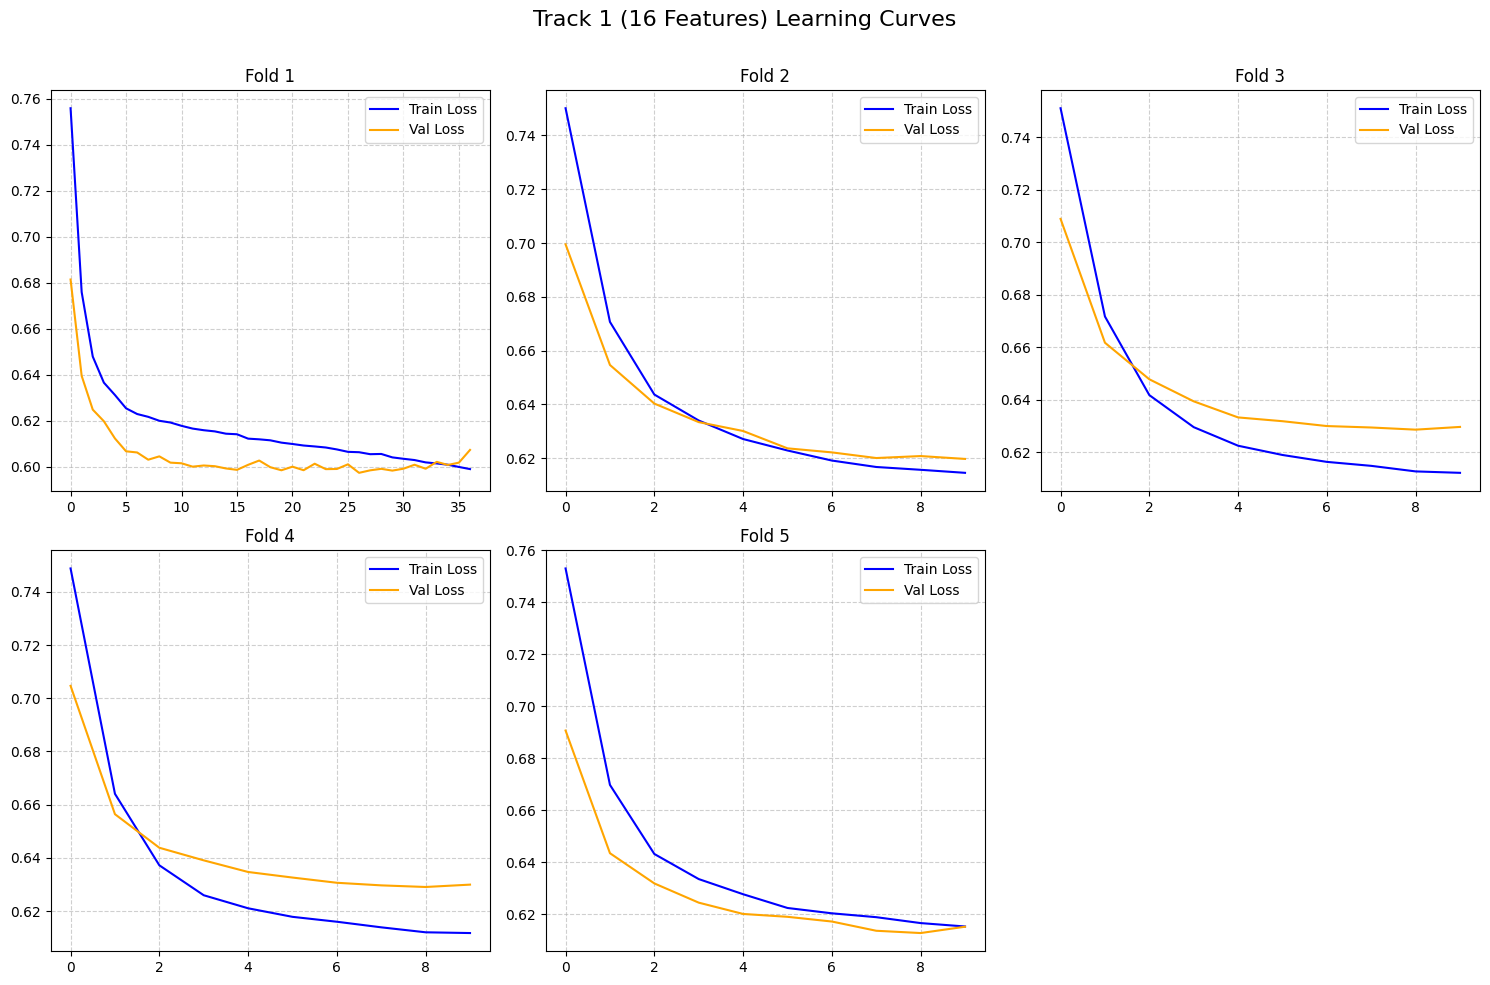


Training Final Master LSTM (16 Features)

FINAL TEST RESULTS (16 FEATURES)
MAE: 0.6705
R²:  0.2055


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold


print("TRACK 1: PREDICTING ALL 16 FEATURES")

OBSERVED_DAYS = 9
PREDICT_DAYS = 21
num_features_in = X_padded.shape[2]
num_target_features = len(final_features_to_use) # 16 features

valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
Y_target_valid = Y_target[valid_user_indices]

X_input = X_valid[:, :OBSERVED_DAYS, :]
# Slicing the target to keep ALL features
Y_future = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :]

X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_input, Y_future, Y_target_valid, test_size=0.2, random_state=42
)

def build_lstm_model_16():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_target_features),
        Reshape((PREDICT_DAYS, num_target_features))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

print(f"\nStarting 5-Fold Cross Validation (16 Features)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores = []
all_histories = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    model_cv = build_lstm_model_16()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores.append(fold_loss)
    all_histories.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores):.4f}")

# Plotting
plt.figure(figsize=(15, 10))
plt.suptitle('Track 1 (16 Features) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

print("\nTraining Final Master LSTM (16 Features)")
master_model_16 = build_lstm_model_16()
master_model_16.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_16 = master_model_16.predict(X_test, verbose=0)
y_test_flat = y_test.reshape(y_test.shape[0], -1)
y_pred_16_flat = y_pred_16.reshape(y_pred_16.shape[0], -1)

print(f"\nFINAL TEST RESULTS (16 FEATURES)")
print(f"MAE: {mean_absolute_error(y_test_flat, y_pred_16_flat):.4f}")
print(f"R²:  {r2_score(y_test_flat, y_pred_16_flat):.4f}")

Predicting 8 biomarkers

TRACK 2: PREDICTING 8 BIOMARKERS ONLY

Starting 5-Fold Cross Validation (8 Biomarkers)
Fold 1 MAE: 0.4410
Fold 2 MAE: 0.5903
Fold 3 MAE: 0.6093
Fold 4 MAE: 0.5886
Fold 5 MAE: 0.5938
Average Validation MAE: 0.5646


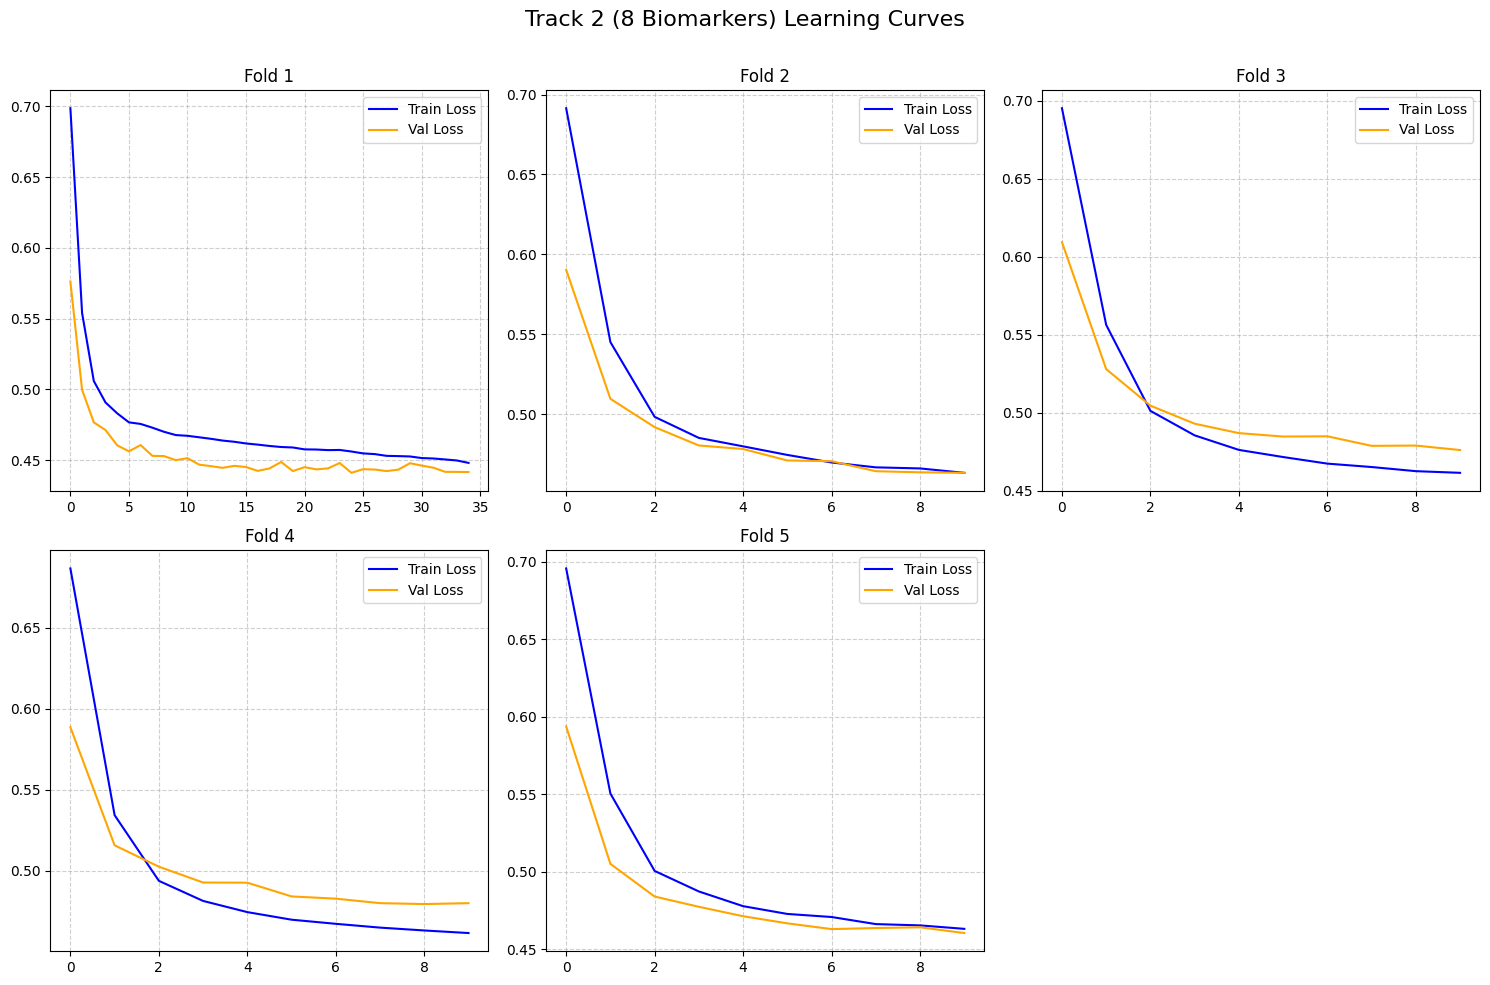


Training Final Master LSTM (8 Biomarkers)

FINAL TEST RESULTS (8 BIOMARKERS)
MAE: 0.5507
R²:  0.3928


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("TRACK 2: PREDICTING 8 BIOMARKERS ONLY")

OBSERVED_DAYS = 9
PREDICT_DAYS = 21
num_features_in = X_padded.shape[2]
num_target_features = len(final_biomarker_features) # 8 features
biomarker_indices = [final_features_to_use.index(b) for b in final_biomarker_features]

valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
Y_target_valid = Y_target[valid_user_indices]

X_input = X_valid[:, :OBSERVED_DAYS, :]
# Slicing the target to keep ONLY biomarkers
Y_future = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :][:, :, biomarker_indices]

X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_input, Y_future, Y_target_valid, test_size=0.2, random_state=42
)

def build_lstm_model_8():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_target_features),
        Reshape((PREDICT_DAYS, num_target_features))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

print(f"\nStarting 5-Fold Cross Validation (8 Biomarkers)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores = []
all_histories = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    model_cv = build_lstm_model_8()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores.append(fold_loss)
    all_histories.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores):.4f}")

# Plotting
plt.figure(figsize=(15, 10))
plt.suptitle('Track 2 (8 Biomarkers) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

print("\nTraining Final Master LSTM (8 Biomarkers)")
master_model_8 = build_lstm_model_8()
master_model_8.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_8 = master_model_8.predict(X_test, verbose=0)
y_test_flat = y_test.reshape(y_test.shape[0], -1)
y_pred_8_flat = y_pred_8.reshape(y_pred_8.shape[0], -1)

print(f"\nFINAL TEST RESULTS (8 BIOMARKERS)")
print(f"MAE: {mean_absolute_error(y_test_flat, y_pred_8_flat):.4f}")
print(f"R²:  {r2_score(y_test_flat, y_pred_8_flat):.4f}")

<h3>2. Bidirectional LSTM</h3>

Predicting 16 features (BiLSTM)

TRACK 1: BiLSTM PREDICTING ALL 16 FEATURES

Starting 5-Fold Cross Validation (16 Features)
Fold 1 MAE: 0.6003
Fold 2 MAE: 0.6904
Fold 3 MAE: 0.7035
Fold 4 MAE: 0.7010
Fold 5 MAE: 0.6879
Average Validation MAE: 0.6766


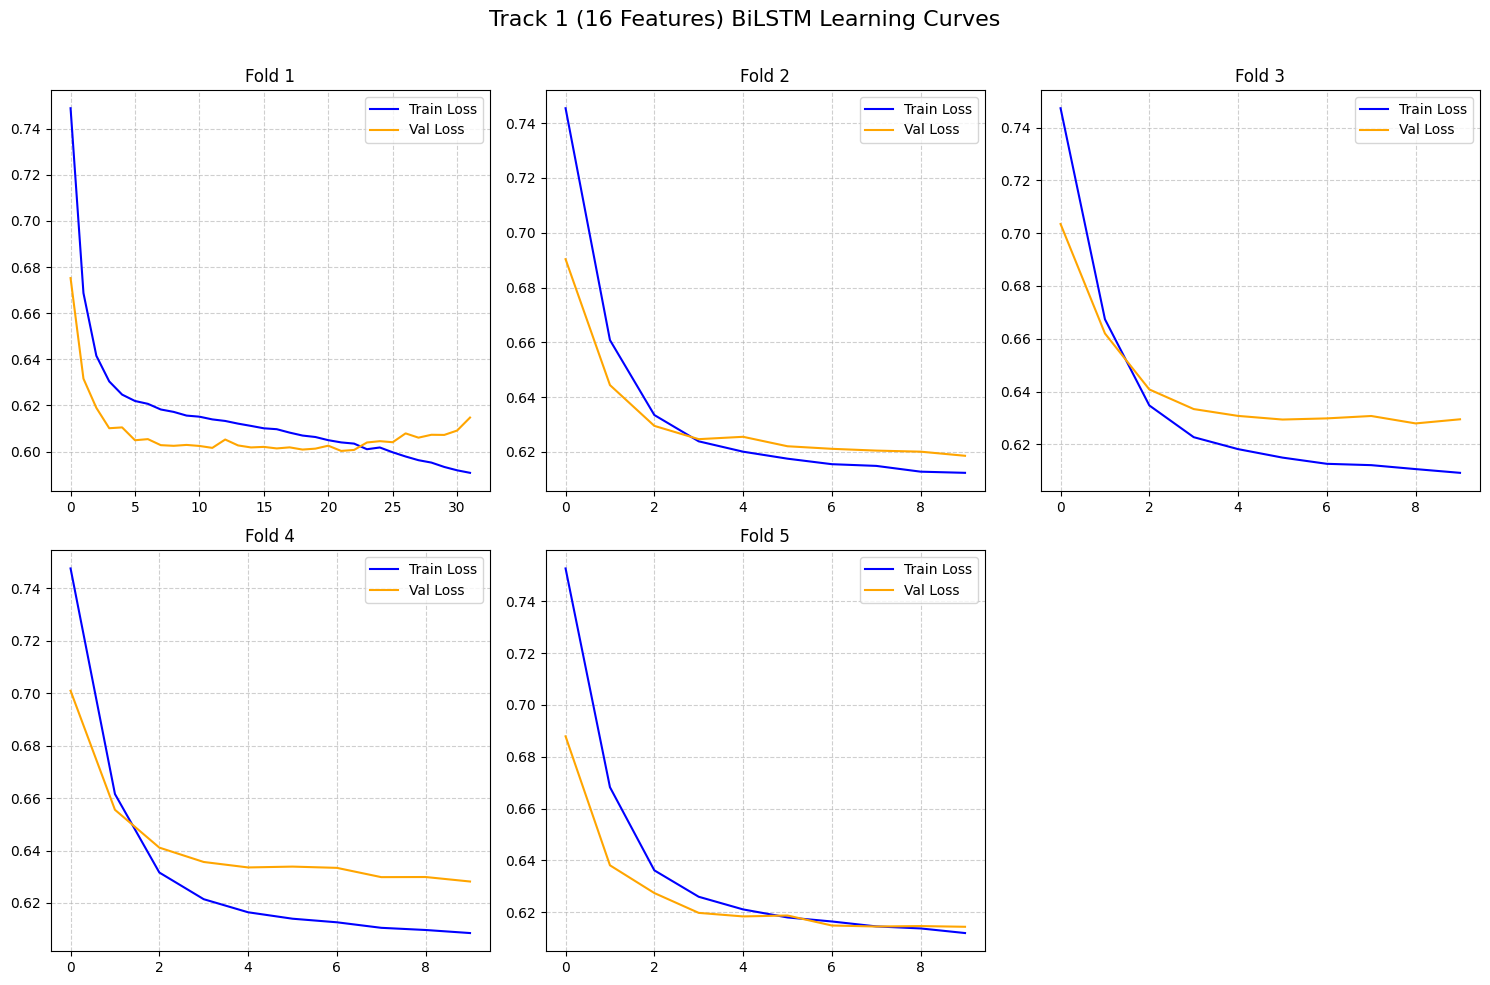


Training Final Master BiLSTM (16 Features)

MODEL COMPARISON (16 FEATURES): Standard LSTM vs BiLSTM
Standard LSTM MAE: 0.6705
BiLSTM MAE:        0.6619  <-- (Lower is better)
Standard LSTM R²:  0.2055
BiLSTM R²:         0.2261  <-- (Higher is better)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("TRACK 1: BiLSTM PREDICTING ALL 16 FEATURES")


OBSERVED_DAYS = 9
PREDICT_DAYS = 21
num_features_in = X_padded.shape[2]
num_target_features_16 = len(final_features_to_use) # 16 features

valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
Y_target_valid = Y_target[valid_user_indices]

X_input = X_valid[:, :OBSERVED_DAYS, :]
Y_future_16 = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :] # All 16

X_train, X_test, y_train_16, y_test_16, _, _ = train_test_split(
    X_input, Y_future_16, Y_target_valid, test_size=0.2, random_state=42
)

# MODEL
def build_bilstm_model_16():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_target_features_16),
        Reshape((PREDICT_DAYS, num_target_features_16))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (16 Features)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_bi_16 = []
all_histories_bi_16 = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_16[train_idx], y_train_16[val_idx]

    model_cv_bi_16 = build_bilstm_model_16()
    history_bi_16 = model_cv_bi_16.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                       epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_bi_16 = model_cv_bi_16.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_bi_16.append(fold_loss_bi_16)
    all_histories_bi_16.append(history_bi_16.history)
    print(f"Fold {fold_no} MAE: {fold_loss_bi_16:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_bi_16):.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 1 (16 Features) BiLSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_bi_16):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# 5. MASTER MODEL & COMPARISON
print("\nTraining Final Master BiLSTM (16 Features)")
master_bilstm_16 = build_bilstm_model_16()
master_bilstm_16.fit(X_train, y_train_16, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_bi_16 = master_bilstm_16.predict(X_test, verbose=0)
y_test_16_flat = y_test_16.reshape(y_test_16.shape[0], -1)
y_pred_bi_16_flat = y_pred_bi_16.reshape(y_pred_bi_16.shape[0], -1)

mae_bi_16 = mean_absolute_error(y_test_16_flat, y_pred_bi_16_flat)
r2_bi_16 = r2_score(y_test_16_flat, y_pred_bi_16_flat)

# Grab Standard LSTM metrics from previous run
try:
    mae_std_16 = mean_absolute_error(y_test_16_flat, y_pred_16_flat)
    r2_std_16 = r2_score(y_test_16_flat, y_pred_16_flat)
except NameError:
    mae_std_16, r2_std_16 = 0, 0 # Fallback if previous cell wasn't run

print(f"\nMODEL COMPARISON (16 FEATURES): Standard LSTM vs BiLSTM")
print(f"Standard LSTM MAE: {mae_std_16:.4f}")
print(f"BiLSTM MAE:        {mae_bi_16:.4f}  <-- (Lower is better)")
print(f"Standard LSTM R²:  {r2_std_16:.4f}")
print(f"BiLSTM R²:         {r2_bi_16:.4f}  <-- (Higher is better)")

Predicting 8 features (BiLSTM)

TRACK 2: BiLSTM PREDICTING 8 BIOMARKERS ONLY

Starting 5-Fold Cross Validation (8 Biomarkers)
Fold 1 MAE: 0.4418
Fold 2 MAE: 0.5796
Fold 3 MAE: 0.5913
Fold 4 MAE: 0.5796
Fold 5 MAE: 0.5630
Average Validation MAE: 0.5511


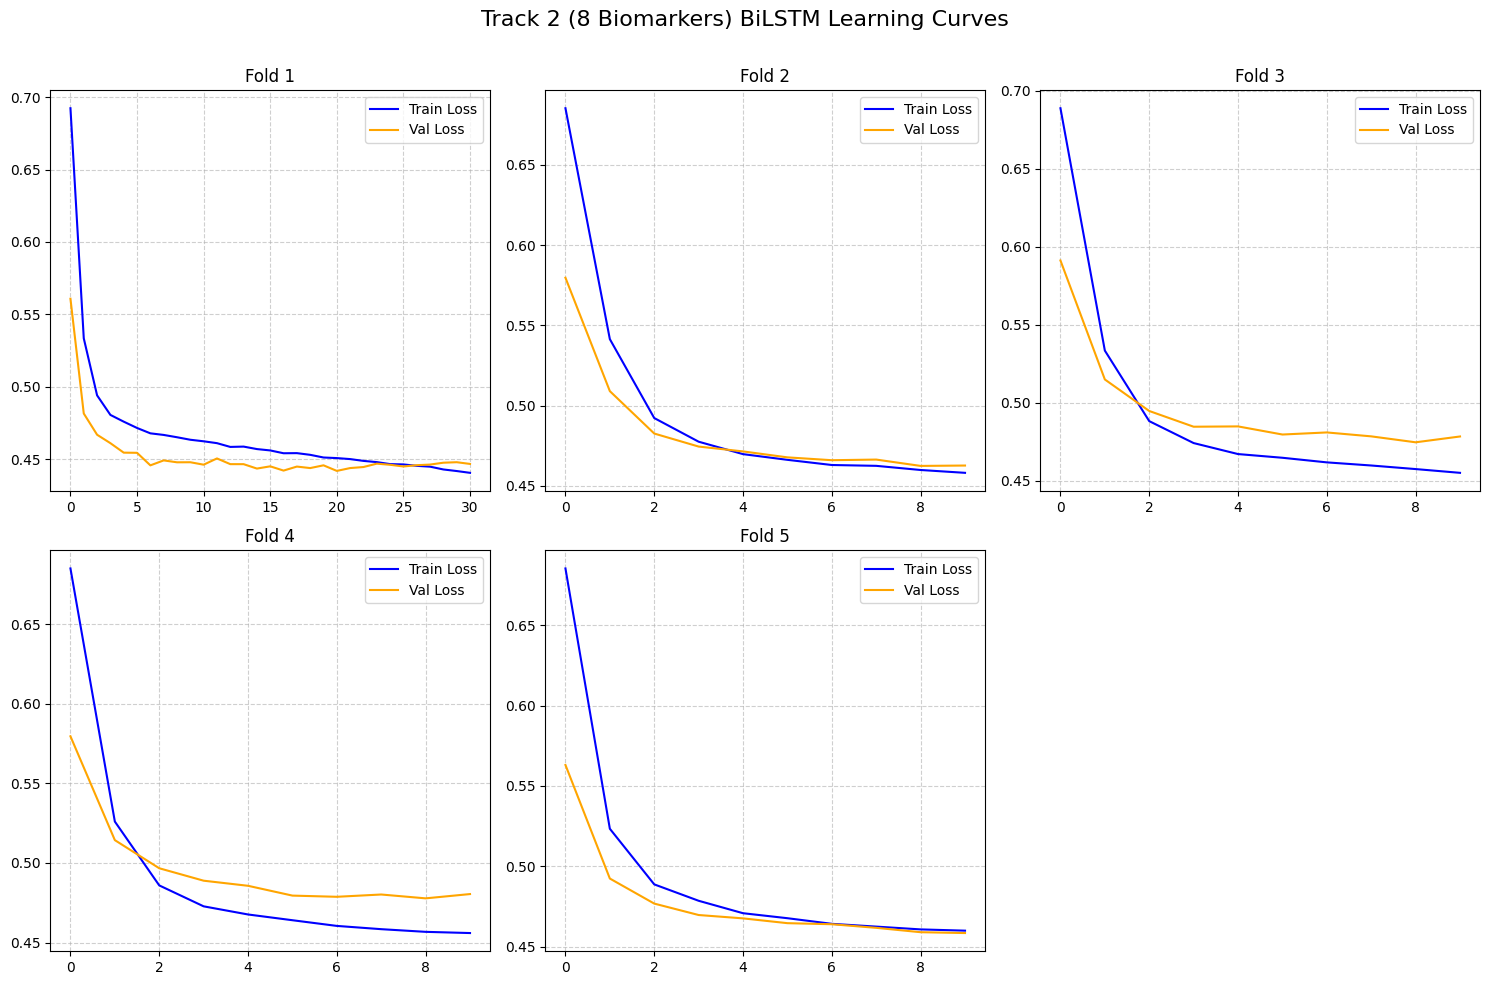


Training Final Master BiLSTM (8 Biomarkers)

MODEL COMPARISON (8 BIOMARKERS): Standard LSTM vs BiLSTM
Standard LSTM MAE: 0.5507
BiLSTM MAE:        0.5506  <-- (Lower is better)
Standard LSTM R² (8 features):  0.3928
BiLSTM R² (8 features):         0.4076  <-- (Higher is better)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold


print("TRACK 2: BiLSTM PREDICTING 8 BIOMARKERS ONLY")

OBSERVED_DAYS = 9
PREDICT_DAYS = 21
num_features_in = X_padded.shape[2]
num_target_features_8 = len(final_biomarker_features) # 8 biomarkers
biomarker_indices = [final_features_to_use.index(b) for b in final_biomarker_features]

valid_user_indices = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBSERVED_DAYS + PREDICT_DAYS - 1, 0]):
        valid_user_indices.append(i)

X_valid = X_padded[valid_user_indices]
Y_target_valid = Y_target[valid_user_indices]

X_input = X_valid[:, :OBSERVED_DAYS, :]
Y_future_8 = X_valid[:, OBSERVED_DAYS : OBSERVED_DAYS + PREDICT_DAYS, :][:, :, biomarker_indices] # Only 8

X_train, X_test, y_train_8, y_test_8, _, _ = train_test_split(
    X_input, Y_future_8, Y_target_valid, test_size=0.2, random_state=42
)

# MODEL
def build_bilstm_model_8():
    model = Sequential([
        Input(shape=(OBSERVED_DAYS, num_features_in)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PREDICT_DAYS * num_target_features_8),
        Reshape((PREDICT_DAYS, num_target_features_8))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (8 Biomarkers)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_bi_8 = []
all_histories_bi_8 = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_8[train_idx], y_train_8[val_idx]

    model_cv_bi_8 = build_bilstm_model_8()
    history_bi_8 = model_cv_bi_8.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                     epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_bi_8 = model_cv_bi_8.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_bi_8.append(fold_loss_bi_8)
    all_histories_bi_8.append(history_bi_8.history)
    print(f"Fold {fold_no} MAE: {fold_loss_bi_8:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_bi_8):.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 2 (8 Biomarkers) BiLSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_bi_8):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


print("\nTraining Final Master BiLSTM (8 Biomarkers)")
master_bilstm_8 = build_bilstm_model_8()
master_bilstm_8.fit(X_train, y_train_8, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_bi_8 = master_bilstm_8.predict(X_test, verbose=0)
y_test_8_flat = y_test_8.reshape(y_test_8.shape[0], -1)
y_pred_bi_8_flat = y_pred_bi_8.reshape(y_pred_bi_8.shape[0], -1)

mae_bi_8 = mean_absolute_error(y_test_8_flat, y_pred_bi_8_flat)
r2_bi_8 = r2_score(y_test_8_flat, y_pred_bi_8_flat)

# Grabbing Standard LSTM metrics from previous run
try:
    mae_std_8 = mean_absolute_error(y_test_8_flat, y_pred_8_flat)
    r2_std_8 = r2_score(y_test_8_flat, y_pred_8_flat)
except NameError:
    mae_std_8, r2_std_8 = 0, 0 # Fallback if previous cell wasn't run

print(f"\nMODEL COMPARISON (8 BIOMARKERS): Standard LSTM vs BiLSTM")
print(f"Standard LSTM MAE: {mae_std_8:.4f}")
print(f"BiLSTM MAE:        {mae_bi_8:.4f}  <-- (Lower is better)")
print(f"Standard LSTM R² (8 features):  {r2_std_8:.4f}")
print(f"BiLSTM R² (8 features):         {r2_bi_8:.4f}  <-- (Higher is better)")

Comparing the resuls with the Naive Baseline model (LOCF)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("NAIVE BASELINE (Last Observation Carried Forward) - 16 FEATURES")

# Extracting ALL 16 features from the last observed day (Day 9)
# X_test shape is [Samples, OBSERVED_DAYS, Total_Features]
# By using ':', we safely take all surviving features (both lifestyle and biomarkers)
last_observed_day_16 = X_test[:, -1, :]

# Repeat that single day's values across all future 21 days
# np.repeat copies the Day 9 array across the time axis
naive_y_pred_16 = np.repeat(last_observed_day_16[:, np.newaxis, :], PREDICT_DAYS, axis=1)

# Flatten both arrays to calculate overall metrics
# We use y_test_16 which was defined in the BiLSTM Track 1 block
naive_y_test_flat_16 = y_test_16.reshape(y_test_16.shape[0], -1)
naive_y_pred_flat_16 = naive_y_pred_16.reshape(naive_y_pred_16.shape[0], -1)

# calculating Metrics
naive_mse_16 = mean_squared_error(naive_y_test_flat_16, naive_y_pred_flat_16)
naive_rmse_16 = np.sqrt(naive_mse_16)
naive_mae_16 = mean_absolute_error(naive_y_test_flat_16, naive_y_pred_flat_16)
naive_r2_16 = r2_score(naive_y_test_flat_16, naive_y_pred_flat_16)

naive_sigma_y_16 = np.std(naive_y_test_flat_16)
naive_nrmse_16 = naive_rmse_16 / naive_sigma_y_16 if naive_sigma_y_16 != 0 else 0

print(f"Naive LOCF Metrics (16 Features):")
print(f"MSE:   {naive_mse_16:.4f}")
print(f"RMSE:  {naive_rmse_16:.4f}")
print(f"MAE:   {naive_mae_16:.4f}")
print(f"NRMSE: {naive_nrmse_16:.4f}")
print(f"R²:    {naive_r2_16:.4f}")

# 5. Direct Comparison with BiLSTM (16 Features)
print(" MODEL COMPARISON: BiLSTM vs Naive Baseline (16 Features)")
print(f"BiLSTM MAE: {mae_bi_16:.4f}  |  Naive MAE: {naive_mae_16:.4f}")
print(f"BiLSTM R²:  {r2_bi_16:.4f}  |  Naive R²:  {naive_r2_16:.4f}")

if mae_bi_16 < naive_mae_16:
    print("\nOur BiLSTM is capturing temporal trends and beating the Naive Baseline on all 16 features.")
else:
    print("\nOur BiLSTM is performing worse than the Baseline.")

NAIVE BASELINE (Last Observation Carried Forward) - 16 FEATURES
Naive LOCF Metrics (16 Features):
MSE:   1.2413
RMSE:  1.1141
MAE:   0.7911
NRMSE: 1.1095
R²:    -0.2480
 MODEL COMPARISON: BiLSTM vs Naive Baseline (16 Features)
BiLSTM MAE: 0.6619  |  Naive MAE: 0.7911
BiLSTM R²:  0.2261  |  Naive R²:  -0.2480

Our BiLSTM is capturing temporal trends and beating the Naive Baseline on all 16 features.


<h1>Classification (1D-CNN)</h1>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

print("CLASSIFICATION (CNN)")

# Defining Common Variables for the updated 30-Day Timeline
total_days = OBSERVED_DAYS + PREDICT_DAYS  # 9 + 21 = 30 days
total_features = len(final_features_to_use) # 16 raw features

# Extract true 30-day sequences for all valid patients
X_full_30_days = X_valid[:, :total_days, :]

# Split properly into Train and Test for the CNN!
X_train_gt, X_test_gt, y_train_labels, y_test_labels = train_test_split(
    X_full_30_days, Y_target_valid, test_size=0.2, random_state=42
)


# SCENARIO 1: GROUND TRUTH
print("\nTraining SCENARIO 1: Ground Truth (Perfect 30-Day Data)")

model_cnn_gt = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax') # 5 risk classifications
])

model_cnn_gt.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train on the 80% Training patients
model_cnn_gt.fit(X_train_gt, y_train_labels, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluate on the 20% Test patients
y_pred_probs_gt = model_cnn_gt.predict(X_test_gt, verbose=0)
y_pred_classes_gt = np.argmax(y_pred_probs_gt, axis=1)
gt_acc = accuracy_score(y_test_labels, y_pred_classes_gt)



# SCENARIO 2: HYBRID (Real + BiLSTM Forecasted Data)
print("Training SCENARIO 2: Hybrid Pipeline (9 Real + 21 Forecasted Days)")

# 1. We must generate the 21-day forecast for the TRAINING patients so the CNN has data to learn from
y_pred_train_16 = master_bilstm_16.predict(X_train, verbose=0)

# 2. Simple Lego-Snap Stitching (No more averaging/overwriting!)
# Concatenate Train set (9 real days + 21 predicted days)
train_stitched_sequence = np.concatenate([X_train, y_pred_train_16], axis=1)

# Concatenate Test set (9 real days + 21 predicted days)
# y_pred_bi_16 was already generated in the BiLSTM Track 1 cell!
test_stitched_sequence = np.concatenate([X_test, y_pred_bi_16], axis=1)

model_cnn_hybrid = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn_hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train on the Stitched Hybrid Training Data
model_cnn_hybrid.fit(train_stitched_sequence, y_train_labels, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluate on the Stitched Hybrid Test Data
y_pred_probs_hybrid = model_cnn_hybrid.predict(test_stitched_sequence, verbose=0)
y_pred_classes_hybrid = np.argmax(y_pred_probs_hybrid, axis=1)
hybrid_acc = accuracy_score(y_test_labels, y_pred_classes_hybrid)



# FINAL COMPARISON

print("CLASSIFICATION RESULTS ")
print(f"Ground Truth Accuracy: {gt_acc:.4f}")
print(f"Hybrid Accuracy (BiLSTM 16 Forecast):  {hybrid_acc:.4f}")

if hybrid_acc >= gt_acc * 0.90:
    print("\nSUCCESS: The Hybrid 16-feature pipeline retains over 90% of the Ground Truth accuracy!")
else:
    print("\nThe Hybrid model is losing some accuracy compared to Ground Truth. Predicting 21 days out is noisy, causing the CNN to struggle slightly.")

CLASSIFICATION (CNN)

Training SCENARIO 1: Ground Truth (Perfect 30-Day Data)
Training SCENARIO 2: Hybrid Pipeline (9 Real + 21 Forecasted Days)
CLASSIFICATION RESULTS 
Ground Truth Accuracy: 0.7567
Hybrid Accuracy (BiLSTM 16 Forecast):  0.7600

SUCCESS: The Hybrid 16-feature pipeline retains over 90% of the Ground Truth accuracy!


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

print("CLASSIFICATION METRICS ")
risk_mapping = {
    '0': '0: Normal / Healthy',
    '1': '1: Mildly Elevated',
    '2': '2: Moderate Risk',
    '3': '3: High Risk',
    '4': '4: Critical Risk'
}

# TABLE 1: GROUND TRUTH
print("\nGROUND TRUTH MODEL (Perfect 30-Day Data)")
gt_dict = classification_report(y_test_labels, y_pred_classes_gt, output_dict=True, zero_division=0)
gt_df = pd.DataFrame(gt_dict).transpose()
gt_df = gt_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
gt_metrics_df = gt_df[['precision', 'recall', 'f1-score']].round(4)
gt_metrics_df.index.name = 'Risk State'
gt_metrics_df.reset_index(inplace=True)
gt_metrics_df['Risk State'] = gt_metrics_df['Risk State'].replace(risk_mapping)
print(gt_metrics_df.to_string(index=False))


# TABLE 2: HYBRID MODEL (9 Real + 21 Forecasted)
print("\nHYBRID MODEL (BiLSTM 16-Feature Forecast)")
hybrid_dict = classification_report(y_test_labels, y_pred_classes_hybrid, output_dict=True, zero_division=0)
hybrid_df = pd.DataFrame(hybrid_dict).transpose()
hybrid_df = hybrid_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
hybrid_metrics_df = hybrid_df[['precision', 'recall', 'f1-score']].round(4)
hybrid_metrics_df.index.name = 'Risk State'
hybrid_metrics_df.reset_index(inplace=True)
hybrid_metrics_df['Risk State'] = hybrid_metrics_df['Risk State'].replace(risk_mapping)
print(hybrid_metrics_df.to_string(index=False))

CLASSIFICATION METRICS 

GROUND TRUTH MODEL (Perfect 30-Day Data)
Risk State  precision  recall  f1-score
       1.0     0.6341  0.5821    0.6070
       2.0     0.7949  0.8815    0.8360
       3.0     0.4444  0.1333    0.2051
       4.0     0.0000  0.0000    0.0000

HYBRID MODEL (BiLSTM 16-Feature Forecast)
Risk State  precision  recall  f1-score
       1.0     0.6962  0.4104    0.5164
       2.0     0.7762  0.9289    0.8457
       3.0     0.4167  0.1667    0.2381
       4.0     1.0000  0.2857    0.4444


<h1>PREDICTING 9 DAYS DATA USING FIRST 21 DAYS DATA</h1>

Time Series Random Forest Regressor

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV


print("PHASE 2 PIPELINE: (21 DAYS TO PREDICT 9)")

OBS_21 = 21
PRED_9 = 9

# SLICING DATA
valid_user_indices_rev = []
for i in range(X_padded.shape[0]):
    if not np.isnan(X_padded[i, OBS_21 + PRED_9 - 1, 0]):
        valid_user_indices_rev.append(i)

X_valid_rev = X_padded[valid_user_indices_rev]
Y_target_valid_rev = Y_target[valid_user_indices_rev]
print(f"Valid users with full 30 days of data: {len(X_valid_rev)}")

X_input_rev = X_valid_rev[:, :OBS_21, :] # 21-day context window

# Target 1: All 16 Features (Next 9 Days)
Y_future_all_rev = X_valid_rev[:, OBS_21 : OBS_21 + PRED_9, :]
# Target 2: Only 8 Biomarkers (Next 9 Days)
Y_future_bio_rev = X_valid_rev[:, OBS_21 : OBS_21 + PRED_9, :][:, :, biomarker_indices]

# Flattening for Random Forest
X_input_flat_rev = X_input_rev.reshape(X_input_rev.shape[0], -1)
Y_future_all_flat_rev = Y_future_all_rev.reshape(Y_future_all_rev.shape[0], -1)
Y_future_bio_flat_rev = Y_future_bio_rev.reshape(Y_future_bio_rev.shape[0], -1)

# Splitting
X_train_rev, X_test_rev, y_train_all_rev, y_test_all_rev, y_train_labels_rev, y_test_labels_rev = train_test_split(
    X_input_flat_rev, Y_future_all_flat_rev, Y_target_valid_rev, test_size=0.2, random_state=42
)
_, _, y_train_bio_rev, y_test_bio_rev, _, _ = train_test_split(
    X_input_flat_rev, Y_future_bio_flat_rev, Y_target_valid_rev, test_size=0.2, random_state=42
)

# RANDOM FOREST TRAINING
param_grid = {'n_estimators': [150], 'max_depth': [10]}
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

print("\nTraining Track 1 (predicting all 16 Features)")
grid_all_rev = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=2)
grid_all_rev.fit(X_train_rev, y_train_all_rev)
y_pred_all_rev = grid_all_rev.best_estimator_.predict(X_test_rev)

print("Training Track 2 (predicting 8 Biomarkers Only)")
grid_bio_rev = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=2)
grid_bio_rev.fit(X_train_rev, y_train_bio_rev)
y_pred_bio_rev = grid_bio_rev.best_estimator_.predict(X_test_rev)

# EVALUATION
print("RANDOM FOREST RESULTS (21 days to 9 DAYS)")
r2_all_rf_rev = print_forecasting_metrics(y_test_all_rev, y_pred_all_rev, "Track 1 [All 16 Features]")
r2_bio_rf_rev = print_forecasting_metrics(y_test_bio_rev, y_pred_bio_rev, "Track 2 [8 Biomarkers Only]")

PHASE 2 PIPELINE: (21 DAYS TO PREDICT 9)
Valid users with full 30 days of data: 3000

Training Track 1 (predicting all 16 Features)
Training Track 2 (predicting 8 Biomarkers Only)
RANDOM FOREST RESULTS (21 days to 9 DAYS)

Track 1 [All 16 Features] Performance:
MSE:   0.6418
RMSE:  0.8011
MAE:   0.6018
NRMSE: 0.8078 (Goal: < 1.0)
R²:    0.3432 (Goal: > 0.2)

Track 2 [8 Biomarkers Only] Performance:
MSE:   0.4280
RMSE:  0.6542
MAE:   0.4653
NRMSE: 0.6549 (Goal: < 1.0)
R²:    0.5720 (Goal: > 0.2)


Comparison with Naive Baseline model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


print("NAIVE BASELINE (Last Observation Carried Forward) - 21 to 9")

# Reshape X_test_rev back to 3D to grab the final observed day (Day 21)
X_test_3d_rev = X_test_rev.reshape(X_test_rev.shape[0], OBS_21, num_all_features)

# Extract ALL 16 features from Day 21
last_observed_day_rev = X_test_3d_rev[:, -1, :]

# Repeat that single day's values across the future 9 days
naive_y_pred_rev = np.repeat(last_observed_day_rev[:, np.newaxis, :], PRED_9, axis=1)

# Flatten for metrics
naive_y_test_flat_rev = y_test_all_rev  # Already flat from RF split
naive_y_pred_flat_rev = naive_y_pred_rev.reshape(naive_y_pred_rev.shape[0], -1)

# Calculate Metrics
naive_mse_rev = mean_squared_error(naive_y_test_flat_rev, naive_y_pred_flat_rev)
naive_rmse_rev = np.sqrt(naive_mse_rev)
naive_mae_rev = mean_absolute_error(naive_y_test_flat_rev, naive_y_pred_flat_rev)
naive_r2_rev = r2_score(naive_y_test_flat_rev, naive_y_pred_flat_rev)

print(f"Naive LOCF Metrics (16 Features):")
print(f"MSE:   {naive_mse_rev:.4f}")
print(f"RMSE:  {naive_rmse_rev:.4f}")
print(f"MAE:   {naive_mae_rev:.4f}")
print(f"R²:    {naive_r2_rev:.4f}")

# 6. Comparison
print("MODEL COMPARISON: Random Forest vs Naive Baseline (21 -> 9)")
# Assuming r2_all_rf_rev from previous block returns a single float
rf_r2_val = r2_all_rf_rev[0] if isinstance(r2_all_rf_rev, list) else r2_all_rf_rev
print(f"Random Forest (16 Feat) R²: {rf_r2_val:.4f}  |  Naive R²: {naive_r2_rev:.4f}")

if rf_r2_val > naive_r2_rev:
    print("\nThe model beat the Naive Baseline.")
else:
    print("\nThe Naive Baseline won.")

NAIVE BASELINE (Last Observation Carried Forward) - 21 to 9
Naive LOCF Metrics (16 Features):
MSE:   1.0501
RMSE:  1.0247
MAE:   0.7150
R²:    -0.0779
MODEL COMPARISON: Random Forest vs Naive Baseline (21 -> 9)
Random Forest (16 Feat) R²: 0.3432  |  Naive R²: -0.0779

The model beat the Naive Baseline.


<h1> Standard LSTM</h1>
Predicting all 16 Features (21 to 9 Days)

STANDARD LSTM PREDICTING ALL 16 FEATURES (21 -> 9)

Starting 5-Fold Cross Validation (16 Features)
Fold 1 MAE: 0.5539
Fold 2 MAE: 0.5499
Fold 3 MAE: 0.6944
Fold 4 MAE: 0.6872
Fold 5 MAE: 0.6717
Average Validation MAE: 0.6314


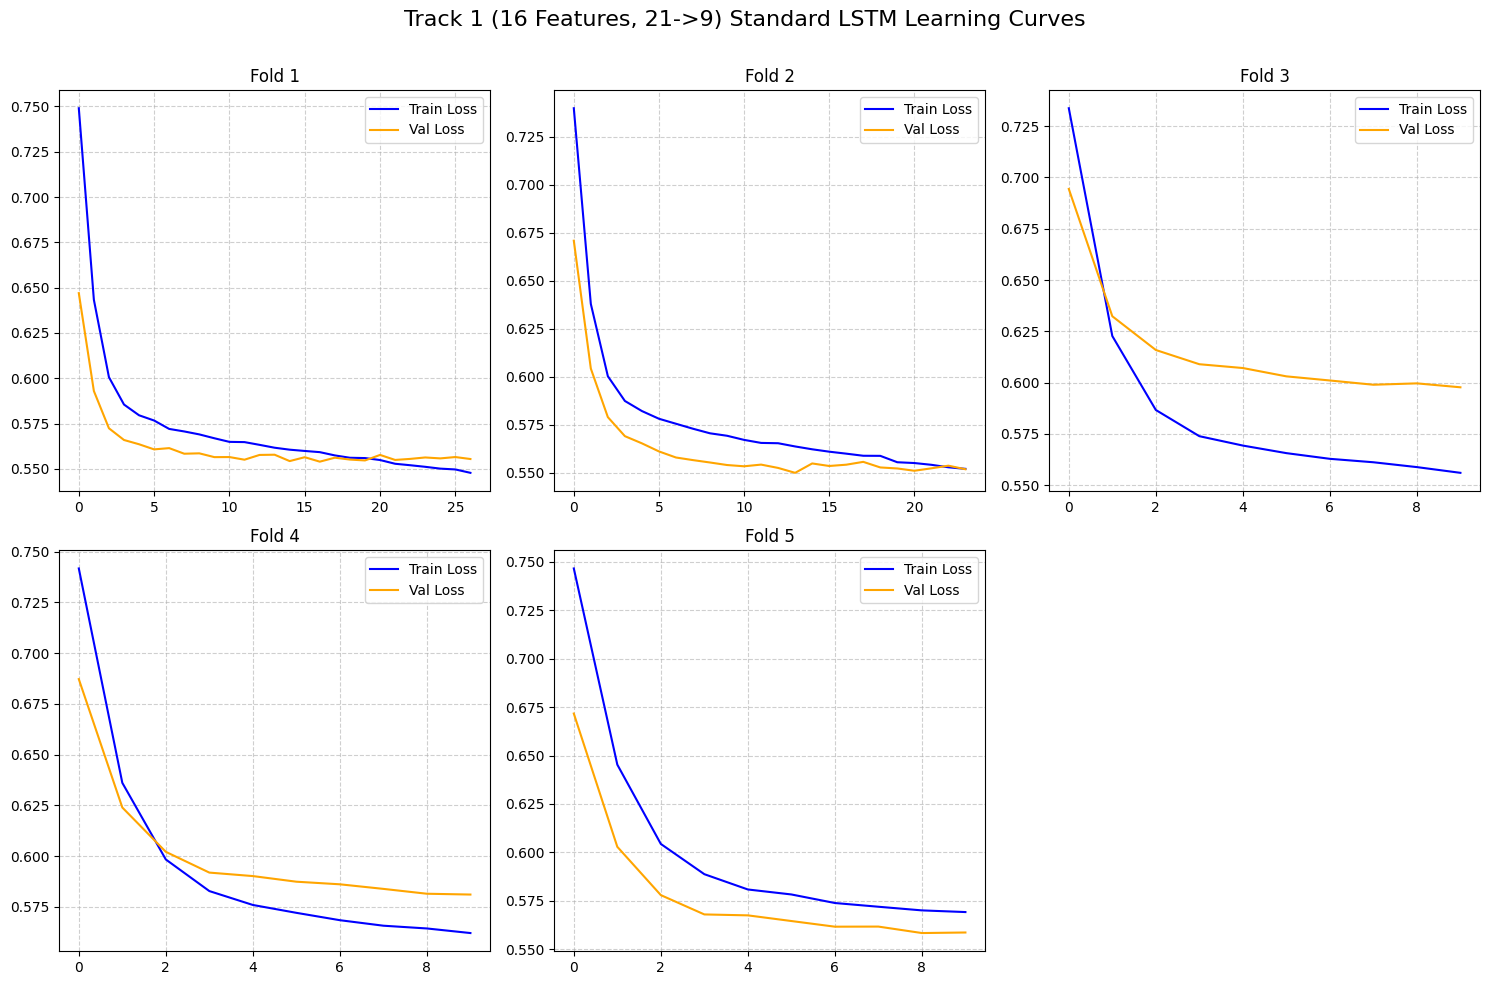


Training Final Master LSTM (16 Features)

FINAL TEST RESULTS (16 FEATURES, 21->9 DAYS)
Standard LSTM MAE: 0.6387
Standard LSTM R²:  0.2602


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("STANDARD LSTM PREDICTING ALL 16 FEATURES (21 -> 9)")

OBS_21 = 21
PRED_9 = 9
num_features_in = X_input_rev.shape[2]
num_target_features_16 = len(final_features_to_use) # 16 features

# 1. Fresh split using the 3D data we sliced in the RF step
X_train_3d_rev, X_test_3d_rev, y_train_16_rev, y_test_16_rev = train_test_split(
    X_input_rev, Y_future_all_rev, test_size=0.2, random_state=42
)

# MODEL
def build_lstm_model_16_rev():
    model = Sequential([
        Input(shape=(OBS_21, num_features_in)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PRED_9 * num_target_features_16),
        Reshape((PRED_9, num_target_features_16))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (16 Features)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_16_rev = []
all_histories_16_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_16_rev[train_idx], y_train_16_rev[val_idx]

    model_cv_16_rev = build_lstm_model_16_rev()
    history_16_rev = model_cv_16_rev.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                         epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_16_rev = model_cv_16_rev.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_16_rev.append(fold_loss_16_rev)
    all_histories_16_rev.append(history_16_rev.history)
    print(f"Fold {fold_no} MAE: {fold_loss_16_rev:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_16_rev):.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 1 (16 Features, 21->9) Standard LSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_16_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MASTER MODEL & EVALUATION
print("\nTraining Final Master LSTM (16 Features)")
master_lstm_16_rev = build_lstm_model_16_rev()
master_lstm_16_rev.fit(X_train_3d_rev, y_train_16_rev, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_std_16_rev = master_lstm_16_rev.predict(X_test_3d_rev, verbose=0)
y_test_16_flat_rev = y_test_16_rev.reshape(y_test_16_rev.shape[0], -1)
y_pred_std_16_flat_rev = y_pred_std_16_rev.reshape(y_pred_std_16_rev.shape[0], -1)

mae_std_16_rev = mean_absolute_error(y_test_16_flat_rev, y_pred_std_16_flat_rev)
r2_std_16_rev = r2_score(y_test_16_flat_rev, y_pred_std_16_flat_rev)

print(f"\nFINAL TEST RESULTS (16 FEATURES, 21->9 DAYS)")
print(f"Standard LSTM MAE: {mae_std_16_rev:.4f}")
print(f"Standard LSTM R²:  {r2_std_16_rev:.4f}")

<h1>Standard LSTM </h1>
Predicting ONLY 8 Biomarkers (21 to 9 Days)

TRACK 2: STANDARD LSTM PREDICTING 8 BIOMARKERS ONLY (21 -> 9)

Starting 5-Fold Cross Validation (8 Biomarkers)
Fold 1 MAE: 0.3887
Fold 2 MAE: 0.5556
Fold 3 MAE: 0.5849
Fold 4 MAE: 0.5741
Fold 5 MAE: 0.5471
Average Validation MAE: 0.5301


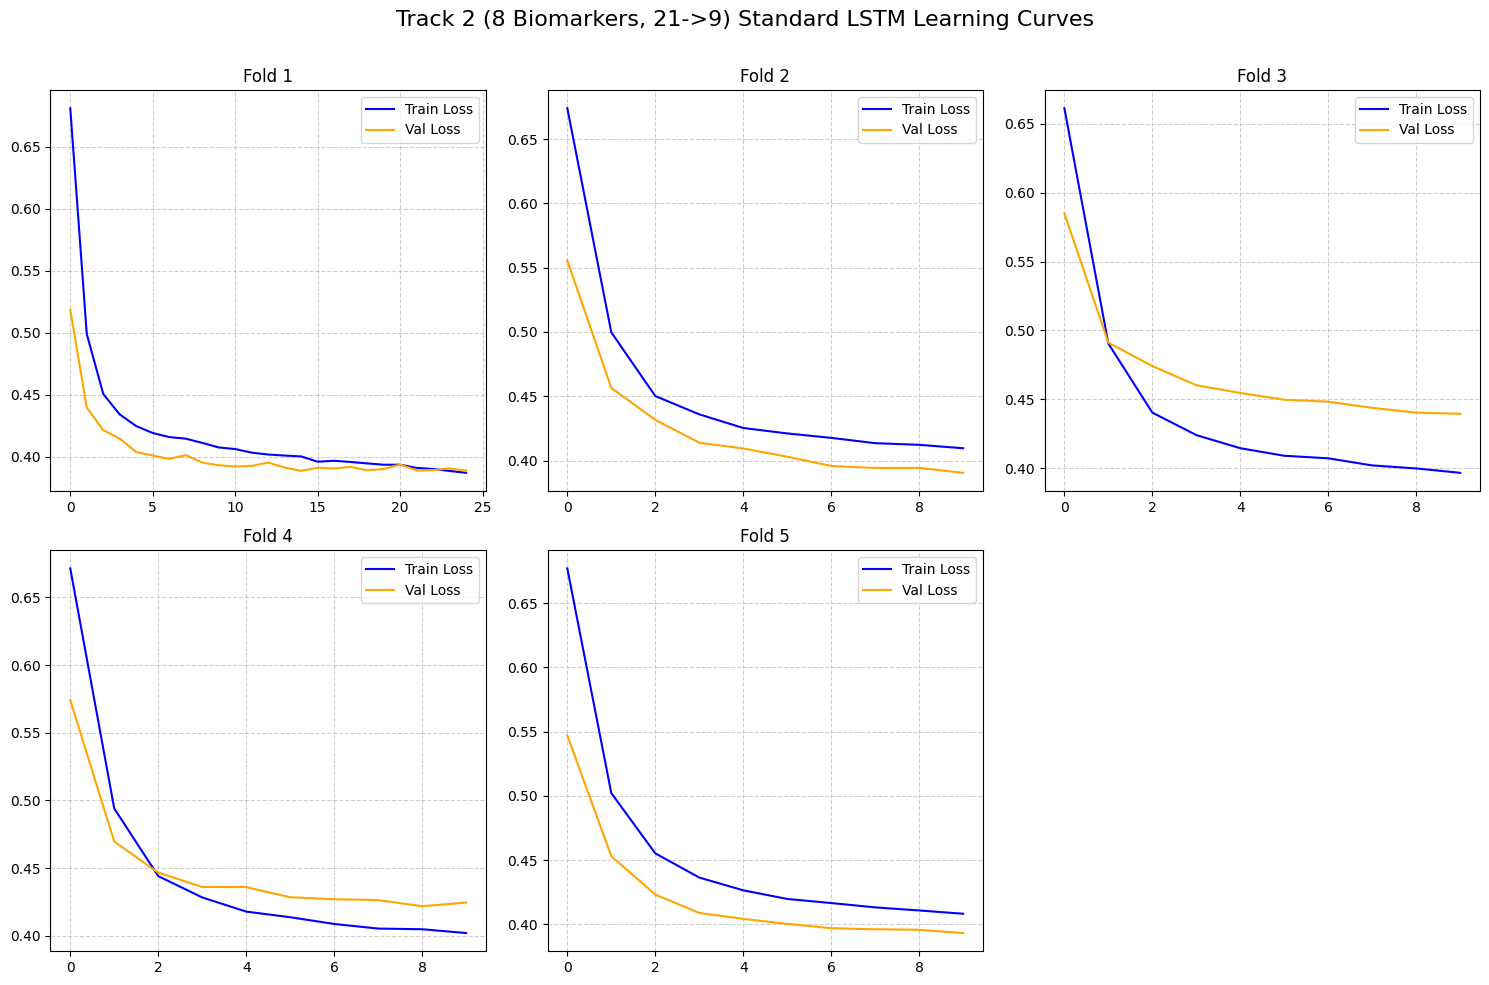


Training Final Master LSTM (8 Biomarkers)

FINAL TEST RESULTS (8 BIOMARKERS, 21->9 DAYS)
Standard LSTM MAE: 0.5163
Standard LSTM R²:  0.4708


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("TRACK 2: STANDARD LSTM PREDICTING 8 BIOMARKERS ONLY (21 -> 9)")

OBS_21 = 21
PRED_9 = 9
num_features_in = X_input_rev.shape[2]
num_target_features_8 = len(final_biomarker_features) # 8 biomarkers

# split using the 3D data
_, _, y_train_8_rev, y_test_8_rev = train_test_split(
    X_input_rev, Y_future_bio_rev, test_size=0.2, random_state=42
)

# MODEL
def build_lstm_model_8_rev():
    model = Sequential([
        Input(shape=(OBS_21, num_features_in)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PRED_9 * num_target_features_8),
        Reshape((PRED_9, num_target_features_8))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (8 Biomarkers)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_8_rev = []
all_histories_8_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_8_rev[train_idx], y_train_8_rev[val_idx]

    model_cv_8_rev = build_lstm_model_8_rev()
    history_8_rev = model_cv_8_rev.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                       epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_8_rev = model_cv_8_rev.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_8_rev.append(fold_loss_8_rev)
    all_histories_8_rev.append(history_8_rev.history)
    print(f"Fold {fold_no} MAE: {fold_loss_8_rev:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_8_rev):.4f}")

# 4. PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 2 (8 Biomarkers, 21->9) Standard LSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_8_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MASTER MODEL & EVALUATION
print("\nTraining Final Master LSTM (8 Biomarkers)")
master_lstm_8_rev = build_lstm_model_8_rev()
master_lstm_8_rev.fit(X_train_3d_rev, y_train_8_rev, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_std_8_rev = master_lstm_8_rev.predict(X_test_3d_rev, verbose=0)
y_test_8_flat_rev = y_test_8_rev.reshape(y_test_8_rev.shape[0], -1)
y_pred_std_8_flat_rev = y_pred_std_8_rev.reshape(y_pred_std_8_rev.shape[0], -1)

mae_std_8_rev = mean_absolute_error(y_test_8_flat_rev, y_pred_std_8_flat_rev)
r2_std_8_rev = r2_score(y_test_8_flat_rev, y_pred_std_8_flat_rev)

print(f"\nFINAL TEST RESULTS (8 BIOMARKERS, 21->9 DAYS)")
print(f"Standard LSTM MAE: {mae_std_8_rev:.4f}")
print(f"Standard LSTM R²:  {r2_std_8_rev:.4f}")

<h1>BiLSTM </h1>
Predicting all 16 Features (21 to 9 Days)

TRACK 1: BiLSTM PREDICTING ALL 16 FEATURES (21 -> 9)

Starting 5-Fold Cross Validation (16 Features)
Fold 1 MAE: 0.5558
Fold 2 MAE: 0.5512
Fold 3 MAE: 0.6808
Fold 4 MAE: 0.6706
Fold 5 MAE: 0.6519
Average Validation MAE: 0.6221


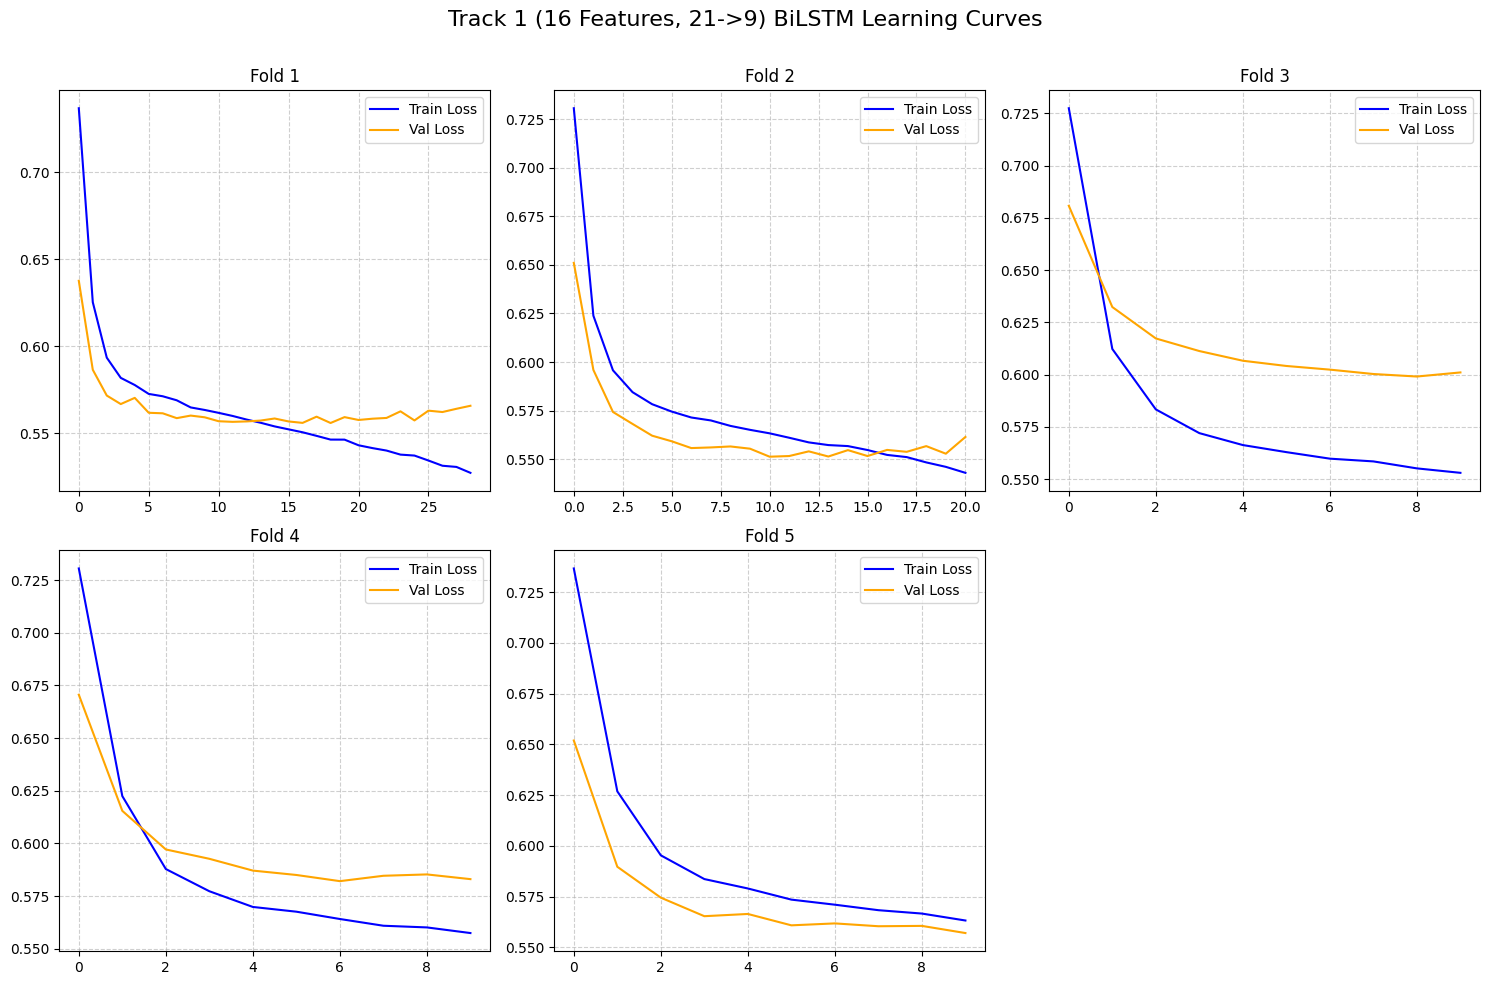


Training Final Master BiLSTM (16 Features)

MODEL COMPARISON (16 FEATURES, 21->9 DAYS): Standard LSTM vs BiLSTM
Standard LSTM MAE: 0.6387
BiLSTM MAE:        0.6294  <-- (Lower is better)
Standard LSTM R²:  0.2602
BiLSTM R²:         0.2877  <-- (Higher is better)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("TRACK 1: BiLSTM PREDICTING ALL 16 FEATURES (21 -> 9)")

OBS_21 = 21
PRED_9 = 9
num_features_in = X_input_rev.shape[2]
num_target_features_16 = len(final_features_to_use) # 16 features

X_train_3d_rev, X_test_3d_rev, y_train_16_rev, y_test_16_rev = train_test_split(
    X_input_rev, Y_future_all_rev, test_size=0.2, random_state=42
)

# MODEL
def build_bilstm_model_16_rev():
    model = Sequential([
        Input(shape=(OBS_21, num_features_in)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PRED_9 * num_target_features_16),
        Reshape((PRED_9, num_target_features_16))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (16 Features)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_bi_16_rev = []
all_histories_bi_16_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_16_rev[train_idx], y_train_16_rev[val_idx]

    model_cv_bi_16_rev = build_bilstm_model_16_rev()
    history_bi_16_rev = model_cv_bi_16_rev.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                               epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_bi_16_rev = model_cv_bi_16_rev.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_bi_16_rev.append(fold_loss_bi_16_rev)
    all_histories_bi_16_rev.append(history_bi_16_rev.history)
    print(f"Fold {fold_no} MAE: {fold_loss_bi_16_rev:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_bi_16_rev):.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 1 (16 Features, 21->9) BiLSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_bi_16_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MASTER MODEL & COMPARISON
print("\nTraining Final Master BiLSTM (16 Features)")
master_bilstm_16_rev = build_bilstm_model_16_rev()
master_bilstm_16_rev.fit(X_train_3d_rev, y_train_16_rev, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_bi_16_rev = master_bilstm_16_rev.predict(X_test_3d_rev, verbose=0)
y_test_16_flat_rev = y_test_16_rev.reshape(y_test_16_rev.shape[0], -1)
y_pred_bi_16_flat_rev = y_pred_bi_16_rev.reshape(y_pred_bi_16_rev.shape[0], -1)

mae_bi_16_rev = mean_absolute_error(y_test_16_flat_rev, y_pred_bi_16_flat_rev)
r2_bi_16_rev = r2_score(y_test_16_flat_rev, y_pred_bi_16_flat_rev)

# Grab Standard LSTM metrics from previous run safely
try:
    mae_std_16_rev_val = mae_std_16_rev
    r2_std_16_rev_val = r2_std_16_rev
except NameError:
    mae_std_16_rev_val, r2_std_16_rev_val = 0, 0

print(f"\nMODEL COMPARISON (16 FEATURES, 21->9 DAYS): Standard LSTM vs BiLSTM")
print(f"Standard LSTM MAE: {mae_std_16_rev_val:.4f}")
print(f"BiLSTM MAE:        {mae_bi_16_rev:.4f}  <-- (Lower is better)")
print(f"Standard LSTM R²:  {r2_std_16_rev_val:.4f}")
print(f"BiLSTM R²:         {r2_bi_16_rev:.4f}  <-- (Higher is better)")

<h1>BiLSTM </h1>
Predicting only 8 Biomarkers (21 to 9 Days)

TRACK 2: BiLSTM PREDICTING 8 BIOMARKERS ONLY (21 -> 9)

Starting 5-Fold Cross Validation (8 Biomarkers)
Fold 1 MAE: 0.3878
Fold 2 MAE: 0.5467
Fold 3 MAE: 0.5577
Fold 4 MAE: 0.5328
Fold 5 MAE: 0.5080
Average Validation MAE: 0.5066


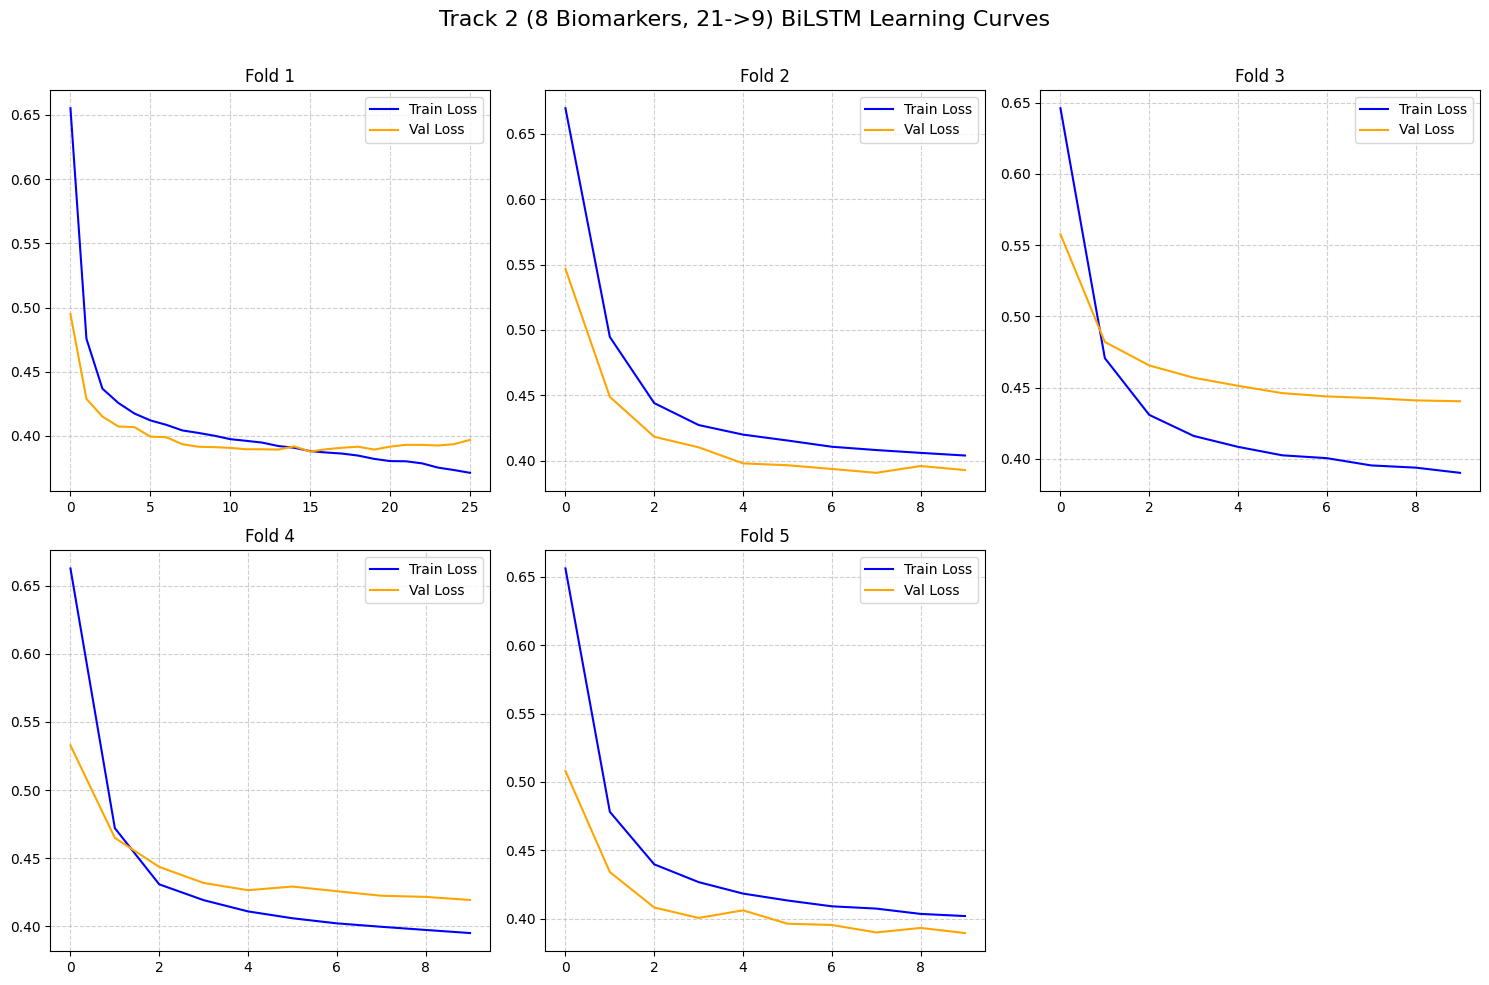


Training Final Master BiLSTM (8 Biomarkers)

MODEL COMPARISON (8 BIOMARKERS, 21->9 DAYS): Standard LSTM vs BiLSTM
Standard LSTM MAE: 0.5163
BiLSTM MAE:        0.4914  <-- (Lower is better)
Standard LSTM R²:  0.4708
BiLSTM R²:         0.5192  <-- (Higher is better)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

print("TRACK 2: BiLSTM PREDICTING 8 BIOMARKERS ONLY (21 -> 9)")

OBS_21 = 21
PRED_9 = 9
num_features_in = X_input_rev.shape[2]
num_target_features_8 = len(final_biomarker_features) # 8 biomarkers

_, _, y_train_8_rev, y_test_8_rev = train_test_split(
    X_input_rev, Y_future_bio_rev, test_size=0.2, random_state=42
)

# MODEL
def build_bilstm_model_8_rev():
    model = Sequential([
        Input(shape=(OBS_21, num_features_in)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(PRED_9 * num_target_features_8),
        Reshape((PRED_9, num_target_features_8))
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# K-FOLD CROSS VALIDATION
print(f"\nStarting 5-Fold Cross Validation (8 Biomarkers)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
cv_mae_scores_bi_8_rev = []
all_histories_bi_8_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_8_rev[train_idx], y_train_8_rev[val_idx]

    model_cv_bi_8_rev = build_bilstm_model_8_rev()
    history_bi_8_rev = model_cv_bi_8_rev.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                                             epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss_bi_8_rev = model_cv_bi_8_rev.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_scores_bi_8_rev.append(fold_loss_bi_8_rev)
    all_histories_bi_8_rev.append(history_bi_8_rev.history)
    print(f"Fold {fold_no} MAE: {fold_loss_bi_8_rev:.4f}")

print(f"Average Validation MAE: {np.mean(cv_mae_scores_bi_8_rev):.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Track 2 (8 Biomarkers, 21->9) BiLSTM Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_bi_8_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MASTER MODEL & COMPARISON
print("\nTraining Final Master BiLSTM (8 Biomarkers)")
master_bilstm_8_rev = build_bilstm_model_8_rev()
master_bilstm_8_rev.fit(X_train_3d_rev, y_train_8_rev, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_bi_8_rev = master_bilstm_8_rev.predict(X_test_3d_rev, verbose=0)
y_test_8_flat_rev = y_test_8_rev.reshape(y_test_8_rev.shape[0], -1)
y_pred_bi_8_flat_rev = y_pred_bi_8_rev.reshape(y_pred_bi_8_rev.shape[0], -1)

mae_bi_8_rev = mean_absolute_error(y_test_8_flat_rev, y_pred_bi_8_flat_rev)
r2_bi_8_rev = r2_score(y_test_8_flat_rev, y_pred_bi_8_flat_rev)

# Grab Standard LSTM metrics from previous run safely
try:
    mae_std_8_rev_val = mae_std_8_rev
    r2_std_8_rev_val = r2_std_8_rev
except NameError:
    mae_std_8_rev_val, r2_std_8_rev_val = 0, 0

print(f"\nMODEL COMPARISON (8 BIOMARKERS, 21->9 DAYS): Standard LSTM vs BiLSTM")
print(f"Standard LSTM MAE: {mae_std_8_rev_val:.4f}")
print(f"BiLSTM MAE:        {mae_bi_8_rev:.4f}  <-- (Lower is better)")
print(f"Standard LSTM R²:  {r2_std_8_rev_val:.4f}")
print(f"BiLSTM R²:         {r2_bi_8_rev:.4f}  <-- (Higher is better)")

Comparison with the Naive Baseline model

In [ ]:
print("COMPARISON (21 -> 9 DAYS): BiLSTM vs NAIVE BASELINE")

print(f"BiLSTM (16 Features) MAE: {mae_bi_16_rev:.4f}  |  Naive LOCF MAE: {naive_mae_rev:.4f}")
print(f"BiLSTM (16 Features) R²:  {r2_bi_16_rev:.4f}  |  Naive LOCF R²:  {naive_r2_rev:.4f}")

if mae_bi_16_rev < naive_mae_rev:
    print("BiLSTM successfully learned the temporal patterns and outperformed the Naive Baseline.")
else:
    print("The Naive Baseline won. With only 9 days to predict, copying the 21st day is a very strong baseline that is hard to beat.")

COMPARISON (21 -> 9 DAYS): BiLSTM vs NAIVE BASELINE
BiLSTM (16 Features) MAE: 0.6294  |  Naive LOCF MAE: 0.7150
BiLSTM (16 Features) R²:  0.2877  |  Naive LOCF R²:  -0.0779
BiLSTM successfully learned the temporal patterns and outperformed the Naive Baseline.


<h1>CLASSIFICATION (CNN)</h1>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


print("FINAL CLASSIFICATION (CNN) - 21 TO 9 DAYS")

# Common Variables for the 30-Day Timeline
total_days = OBS_21 + PRED_9  # 21 + 9 = 30 days
total_features = len(final_features_to_use) # 16 raw features

# Extracting true 30-day sequences for all valid Phase 2 patients
X_full_30_days_rev = X_valid_rev[:, :total_days, :]

# Split properly into Train and Test using the same random state
X_train_gt_rev, X_test_gt_rev, y_train_labels_rev, y_test_labels_rev = train_test_split(
    X_full_30_days_rev, Y_target_valid_rev, test_size=0.2, random_state=42
)

# SCENARIO 1: GROUND TRUTH

model_cnn_gt_rev = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax') # 5 risk classifications
])

model_cnn_gt_rev.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train on the 80% Training patients
model_cnn_gt_rev.fit(X_train_gt_rev, y_train_labels_rev, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluate on the 20% Test patients
y_pred_probs_gt_rev = model_cnn_gt_rev.predict(X_test_gt_rev, verbose=0)
y_pred_classes_gt_rev = np.argmax(y_pred_probs_gt_rev, axis=1)
gt_acc_rev = accuracy_score(y_test_labels_rev, y_pred_classes_gt_rev)


# SCENARIO 2: HYBRID (21 Real + 9 BiLSTM Forecasted Days)

# Generating the 9-day forecast for the TRAINING patients using the Phase 2 BiLSTM
y_pred_train_16_rev = master_bilstm_16_rev.predict(X_train_3d_rev, verbose=0)

# (Concatenate 21 real days + 9 predicted days)
train_stitched_sequence_rev = np.concatenate([X_train_3d_rev, y_pred_train_16_rev], axis=1)

# y_pred_bi_16_rev was generated in the BiLSTM Phase 2 cell
test_stitched_sequence_rev = np.concatenate([X_test_3d_rev, y_pred_bi_16_rev], axis=1)

model_cnn_hybrid_rev = Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn_hybrid_rev.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train on the Stitched Hybrid Training Data
model_cnn_hybrid_rev.fit(train_stitched_sequence_rev, y_train_labels_rev, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluate on the Stitched Hybrid Test Data
y_pred_probs_hybrid_rev = model_cnn_hybrid_rev.predict(test_stitched_sequence_rev, verbose=0)
y_pred_classes_hybrid_rev = np.argmax(y_pred_probs_hybrid_rev, axis=1)
hybrid_acc_rev = accuracy_score(y_test_labels_rev, y_pred_classes_hybrid_rev)


# FINAL COMPARISON
print("FINAL CLASSIFICATION RESULTS (21 -> 9 DAYS) ")
print(f"Ground Truth Accuracy (Gold Standard): {gt_acc_rev:.4f}")
print(f"Hybrid Accuracy (BiLSTM 16 Forecast):  {hybrid_acc_rev:.4f}")

if hybrid_acc_rev >= gt_acc_rev * 0.95:
    print("\nSUCCESS: With 21 days of context, the Hybrid model performs almost identically to the Ground Truth")
else:
    print("\nThe Hybrid model is slightly behind, but it should be much closer to Ground Truth than the 9-to-21 pipeline.")

# DETAILED METRICS TABLES

print("CLASSIFICATION METRICS (21 -> 9 DAYS) ")

risk_mapping = {
    '0': '0: Normal / Healthy',
    '1': '1: Mildly Elevated',
    '2': '2: Moderate Risk',
    '3': '3: High Risk',
    '4': '4: Critical Risk'
}

# TABLE 1: GROUND TRUTH
print("\nGROUND TRUTH MODEL (Perfect 30-Day Data)")
gt_dict_rev = classification_report(y_test_labels_rev, y_pred_classes_gt_rev, output_dict=True, zero_division=0)
gt_df_rev = pd.DataFrame(gt_dict_rev).transpose()
gt_df_rev = gt_df_rev.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
gt_metrics_df_rev = gt_df_rev[['precision', 'recall', 'f1-score']].round(4)
gt_metrics_df_rev.index.name = 'Risk State'
gt_metrics_df_rev.reset_index(inplace=True)
gt_metrics_df_rev['Risk State'] = gt_metrics_df_rev['Risk State'].replace(risk_mapping)
print(gt_metrics_df_rev.to_string(index=False))

# TABLE 2: HYBRID MODEL
print("\nHYBRID MODEL (21 Real + 9 Forecasted)")
hybrid_dict_rev = classification_report(y_test_labels_rev, y_pred_classes_hybrid_rev, output_dict=True, zero_division=0)
hybrid_df_rev = pd.DataFrame(hybrid_dict_rev).transpose()
hybrid_df_rev = hybrid_df_rev.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
hybrid_metrics_df_rev = hybrid_df_rev[['precision', 'recall', 'f1-score']].round(4)
hybrid_metrics_df_rev.index.name = 'Risk State'
hybrid_metrics_df_rev.reset_index(inplace=True)
hybrid_metrics_df_rev['Risk State'] = hybrid_metrics_df_rev['Risk State'].replace(risk_mapping)
print(hybrid_metrics_df_rev.to_string(index=False))

FINAL CLASSIFICATION (CNN) - 21 TO 9 DAYS
FINAL CLASSIFICATION RESULTS (21 -> 9 DAYS) 
Ground Truth Accuracy (Gold Standard): 0.7417
Hybrid Accuracy (BiLSTM 16 Forecast):  0.7500

SUCCESS: With 21 days of context, the Hybrid model performs almost identically to the Ground Truth
CLASSIFICATION METRICS (21 -> 9 DAYS) 

GROUND TRUTH MODEL (Perfect 30-Day Data)
Risk State  precision  recall  f1-score
       1.0     0.5839  0.6493    0.6148
       2.0     0.8088  0.8318    0.8201
       3.0     0.4118  0.2333    0.2979
       4.0     0.0000  0.0000    0.0000

HYBRID MODEL (21 Real + 9 Forecasted)
Risk State  precision  recall  f1-score
       1.0     0.6452  0.4478    0.5286
       2.0     0.7859  0.8957    0.8372
       3.0     0.4000  0.2667    0.3200
       4.0     0.6667  0.2857    0.4000


FINAL COMPARISON OF R^2 VALUES

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score

# Helper function to fetch or recalculate R² scores from memory
def safe_get_r2(metric_name, true_name, pred_name):
    # Try to grab the exact metric variable if it exists
    if metric_name in globals():
        val = globals()[metric_name]
        # Handle if the variable is stored inside a list
        if isinstance(val, (list, tuple, np.ndarray)):
            return round(val[0], 4)
        return round(val, 4)

    # If the variable wasn't saved, recalculate it on the fly using the arrays!
    if true_name in globals() and pred_name in globals():
        return round(r2_score(globals()[true_name], globals()[pred_name]), 4)

    # Safe fallback if the cell was never run
    return "Not Run"

summary_data = {
    "Model Type": [
        "Random Forest", "Random Forest",
        "Standard LSTM", "Standard LSTM",
        "BiLSTM", "BiLSTM"
    ],
    "Features": [
        "16 (All)", "8 (Biomarkers Only)",
        "16 (All)", "8 (Biomarkers Only)",
        "16 (All)", "8 (Biomarkers Only)"
    ],
    "Phase 1: 9 -> 21 Days (R²)": [
        safe_get_r2('r2_all', 'y_test_all', 'y_pred_all'),
        safe_get_r2('r2_bio', 'y_test_bio', 'y_pred_bio'),
        safe_get_r2('r2_std_16', 'y_test_flat', 'y_pred_16_flat'),
        safe_get_r2('r2_std_8', 'y_test_flat', 'y_pred_8_flat'),
        safe_get_r2('r2_bi_16', 'y_test_16_flat', 'y_pred_bi_16_flat'),
        safe_get_r2('r2_bi_8', 'y_test_8_flat', 'y_pred_bi_8_flat')
    ],
    "Phase 2: 21 -> 9 Days (R²)": [
        safe_get_r2('r2_all_rf_rev', 'y_test_all_rev', 'y_pred_all_rev'),
        safe_get_r2('r2_bio_rf_rev', 'y_test_bio_rev', 'y_pred_bio_rev'),
        safe_get_r2('r2_std_16_rev', 'y_test_16_flat_rev', 'y_pred_std_16_flat_rev'),
        safe_get_r2('r2_std_8_rev', 'y_test_8_flat_rev', 'y_pred_std_8_flat_rev'),
        safe_get_r2('r2_bi_16_rev', 'y_test_16_flat_rev', 'y_pred_bi_16_flat_rev'),
        safe_get_r2('r2_bi_8_rev', 'y_test_8_flat_rev', 'y_pred_bi_8_flat_rev')
    ]
}

master_summary_df = pd.DataFrame(summary_data)

print("R² SUMMARY TABLE")
print(master_summary_df.to_string(index=False))

R² SUMMARY TABLE
   Model Type            Features  Phase 1: 9 -> 21 Days (R²)  Phase 2: 21 -> 9 Days (R²)
Random Forest            16 (All)                      0.2745                      0.3432
Random Forest 8 (Biomarkers Only)                      0.4887                      0.5720
Standard LSTM            16 (All)                      0.2055                      0.2602
Standard LSTM 8 (Biomarkers Only)                      0.3928                      0.4708
       BiLSTM            16 (All)                      0.2261                      0.2877
       BiLSTM 8 (Biomarkers Only)                      0.4076                      0.5192


<h2>Attention LSTM Predicting 16 Features (9 to 21 Days)</h2>

ATTENTION-LSTM: PREDICTING ALL 16 FEATURES (9 -> 21)

Starting 5-Fold Cross Validation
Fold 1 MAE: 0.6031
Fold 2 MAE: 0.6467
Fold 3 MAE: 0.6569
Fold 4 MAE: 0.6586
Fold 5 MAE: 0.6400


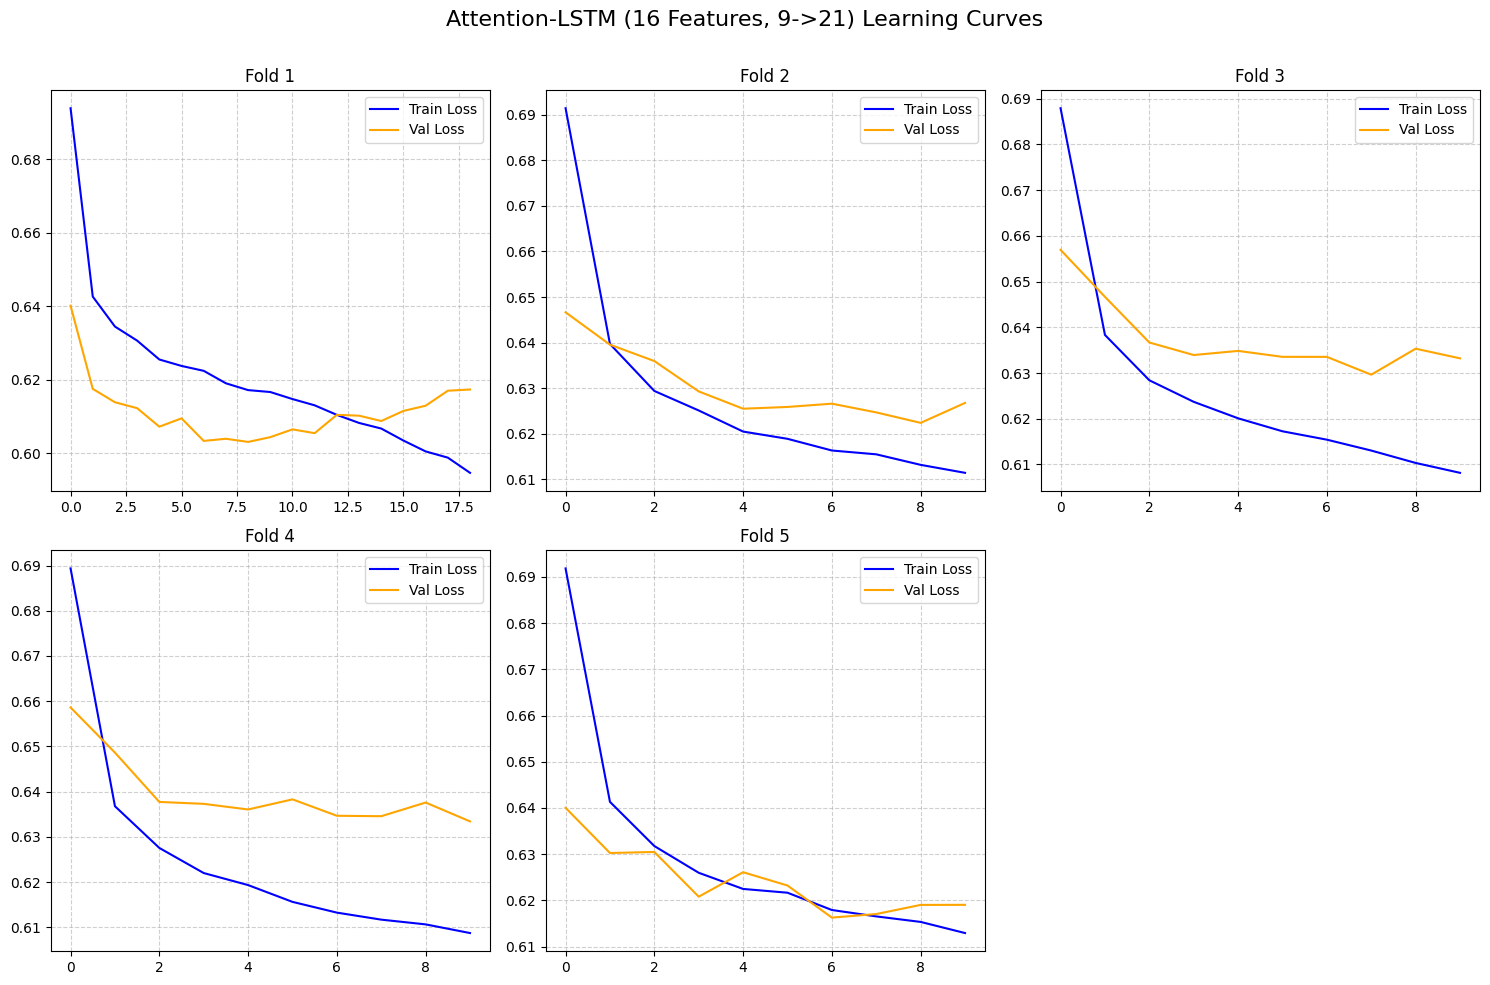


Training Master Attention-LSTM (16 Features)

FINAL METRICS:
MAE: 0.6259
R²:  0.2742


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Reshape, Dropout, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold

print("ATTENTION-LSTM: PREDICTING ALL 16 FEATURES (9 -> 21)")

num_features_in = X_train.shape[2]
num_target_features_16 = y_train_16.shape[2]

# MODEL BUILDER
def build_attention_lstm_16():
    inputs = Input(shape=(OBSERVED_DAYS, num_features_in))

    # LSTM encodes the sequence
    lstm_out = LSTM(128, return_sequences=True)(inputs)

    # Attention Layer
    attention_out = Attention()([lstm_out, lstm_out])
    attention_out = Dropout(0.3)(attention_out)

    # Final decoding
    lstm_out_2 = LSTM(64, return_sequences=False)(attention_out)
    dense_1 = Dense(64, activation='relu')(lstm_out_2)

    outputs = Dense(PREDICT_DAYS * num_target_features_16)(dense_1)
    outputs = Reshape((PREDICT_DAYS, num_target_features_16))(outputs)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mae')
    return model

# 5-FOLD CROSS VALIDATION
print("\nStarting 5-Fold Cross Validation")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cv_mae_att_16 = []
all_histories_att_16 = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_16[train_idx], y_train_16[val_idx]

    model_cv = build_attention_lstm_16()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=150, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_att_16.append(fold_loss)
    all_histories_att_16.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Attention-LSTM (16 Features, 9->21) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_att_16):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MODEL TRAINING
print("\nTraining Master Attention-LSTM (16 Features)")
master_att_16 = build_attention_lstm_16()
master_att_16.fit(X_train, y_train_16, epochs=150, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_att_16 = master_att_16.predict(X_test, verbose=0)
y_test_16_flat = y_test_16.reshape(y_test_16.shape[0], -1)
y_pred_att_16_flat = y_pred_att_16.reshape(y_pred_att_16.shape[0], -1)

mae_att_16 = mean_absolute_error(y_test_16_flat, y_pred_att_16_flat)
r2_att_16 = r2_score(y_test_16_flat, y_pred_att_16_flat)

print(f"\nFINAL METRICS:")
print(f"MAE: {mae_att_16:.4f}")
print(f"R²:  {r2_att_16:.4f}")

<h2>Attention LSTM Predicting 8 Biomarkers (9 to 21 Days)</h2>

 ATTENTION-LSTM: PREDICTING 8 BIOMARKERS (9 -> 21)

Starting 5-Fold Cross Validation
Fold 1 MAE: 0.4500
Fold 2 MAE: 0.5172
Fold 3 MAE: 0.5284
Fold 4 MAE: 0.5086
Fold 5 MAE: 0.5081


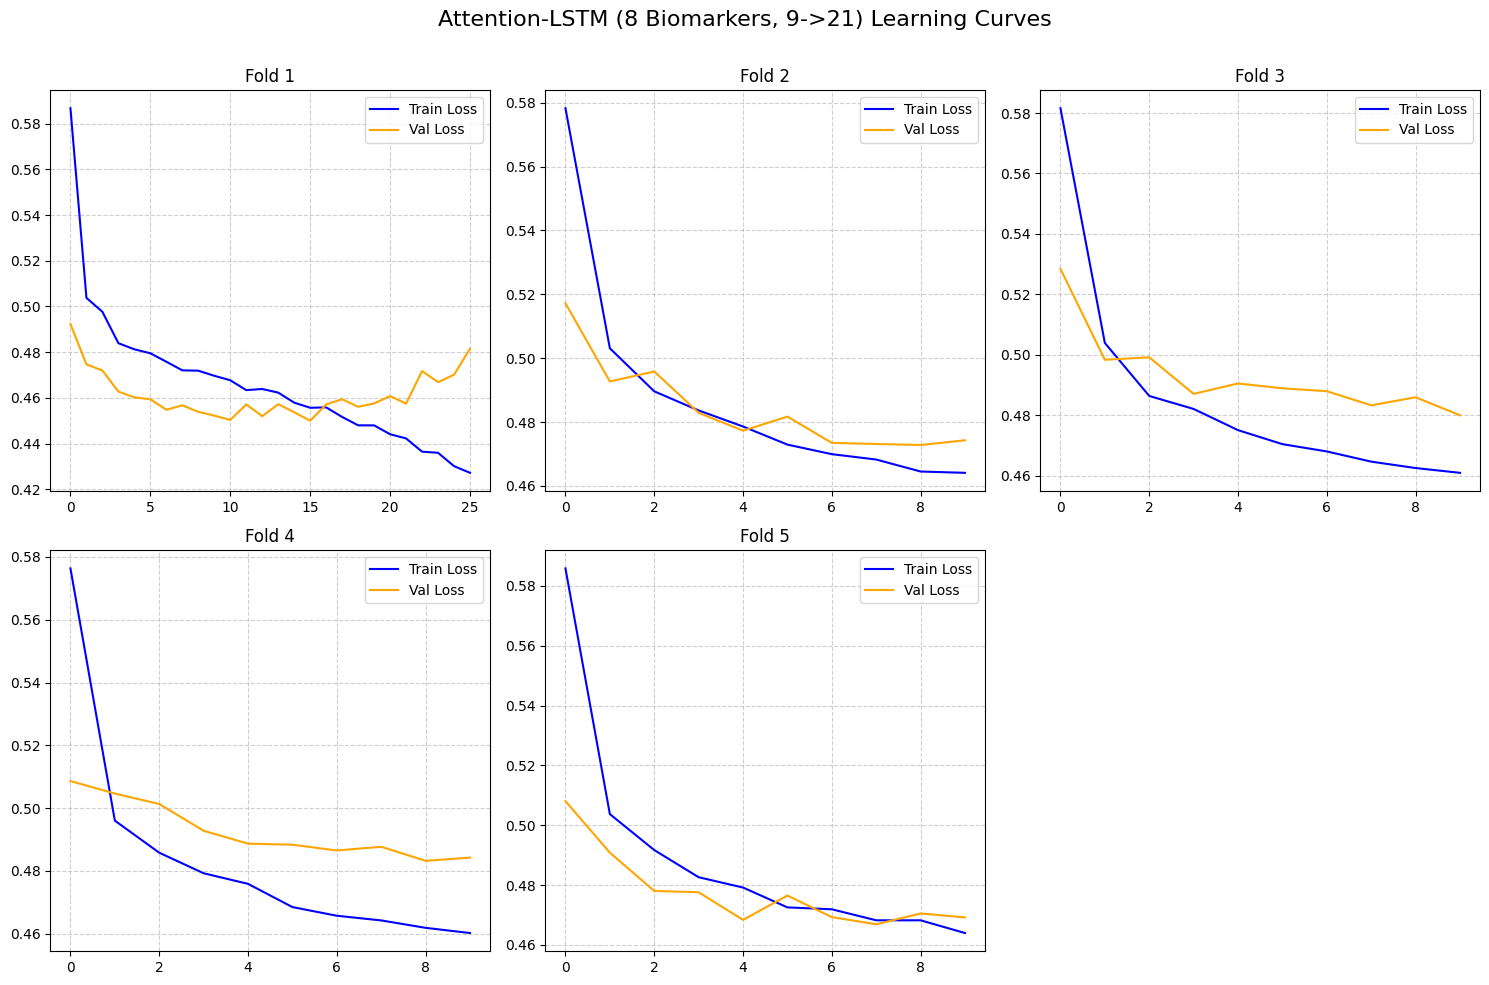


Training Master Attention-LSTM (8 Biomarkers)

FINAL METRICS:
MAE: 0.4881
R²:  0.4929


In [ ]:
print(" ATTENTION-LSTM: PREDICTING 8 BIOMARKERS (9 -> 21)")

num_target_features_8 = y_train_8.shape[2]

# MODEL BUILDER
def build_attention_lstm_8():
    inputs = Input(shape=(OBSERVED_DAYS, num_features_in))
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    attention_out = Attention()([lstm_out, lstm_out])
    attention_out = Dropout(0.3)(attention_out)
    lstm_out_2 = LSTM(64, return_sequences=False)(attention_out)
    dense_1 = Dense(64, activation='relu')(lstm_out_2)

    outputs = Dense(PREDICT_DAYS * num_target_features_8)(dense_1)
    outputs = Reshape((PREDICT_DAYS, num_target_features_8))(outputs)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mae')
    return model

# 5-FOLD CROSS VALIDATION
print("\nStarting 5-Fold Cross Validation")
cv_mae_att_8 = []
all_histories_att_8 = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_8[train_idx], y_train_8[val_idx]

    model_cv = build_attention_lstm_8()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=150, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_att_8.append(fold_loss)
    all_histories_att_8.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Attention-LSTM (8 Biomarkers, 9->21) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_att_8):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MODEL TRAINING
print("\nTraining Master Attention-LSTM (8 Biomarkers)")
master_att_8 = build_attention_lstm_8()
master_att_8.fit(X_train, y_train_8, epochs=150, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_att_8 = master_att_8.predict(X_test, verbose=0)
y_test_8_flat = y_test_8.reshape(y_test_8.shape[0], -1)
y_pred_att_8_flat = y_pred_att_8.reshape(y_pred_att_8.shape[0], -1)

mae_att_8 = mean_absolute_error(y_test_8_flat, y_pred_att_8_flat)
r2_att_8 = r2_score(y_test_8_flat, y_pred_att_8_flat)

print(f"\nFINAL METRICS:")
print(f"MAE: {mae_att_8:.4f}")
print(f"R²:  {r2_att_8:.4f}")

<h2>Hybrid CNN Classification using Attention-LSTM (9 to 21 Days)</h2>

In [ ]:
import pandas as pd
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
from sklearn.metrics import accuracy_score, classification_report

print("CNN CLASSIFICATION: ATTENTION-LSTM HYBRID (9 -> 21)")

# Generating predictions for the training set to properly stitch the history
y_pred_train_att_16 = master_att_16.predict(X_train, verbose=0)

# Stitching (9 Real + 21 Forecasted)
train_stitched_att = np.concatenate([X_train, y_pred_train_att_16], axis=1)
test_stitched_att = np.concatenate([X_test, y_pred_att_16], axis=1)

# Building CNN Model
model_cnn_att = tf.keras.models.Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn_att.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training and Evaluating
print("Training CNN on Attention-LSTM Hybrid Data")
model_cnn_att.fit(train_stitched_att, y_train_labels, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

y_pred_probs_att = model_cnn_att.predict(test_stitched_att, verbose=0)
y_pred_classes_att = np.argmax(y_pred_probs_att, axis=1)
hybrid_acc_att = accuracy_score(y_test_labels, y_pred_classes_att)

print(f"\nAttention Hybrid Accuracy: {hybrid_acc_att:.4f}")

print("\nDETAILED METRICS")
att_dict = classification_report(y_test_labels, y_pred_classes_att, output_dict=True, zero_division=0)
att_df = pd.DataFrame(att_dict).transpose().drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
att_metrics_df = att_df[['precision', 'recall', 'f1-score']].round(4)
att_metrics_df.index.name = 'Risk State'
att_metrics_df.reset_index(inplace=True)
att_metrics_df['Risk State'] = att_metrics_df['Risk State'].replace(risk_mapping)
print(att_metrics_df.to_string(index=False))

CNN CLASSIFICATION: ATTENTION-LSTM HYBRID (9 -> 21)
Training CNN on Attention-LSTM Hybrid Data

Attention Hybrid Accuracy: 0.7517

DETAILED METRICS
Risk State  precision  recall  f1-score
       1.0     0.6018  0.5075    0.5506
       2.0     0.7957  0.8768    0.8343
       3.0     0.4667  0.2333    0.3111
       4.0     0.8571  0.4286    0.5714


<h2>Attention LSTM Predicting 16 Features (21 to 9 Days)</h2>

 ATTENTION-LSTM: PREDICTING ALL 16 FEATURES (21 -> 9)

Starting 5-Fold Cross Validation
Fold 1 MAE: 0.5915
Fold 2 MAE: 0.6071
Fold 3 MAE: 0.6471
Fold 4 MAE: 0.6192
Fold 5 MAE: 0.6001


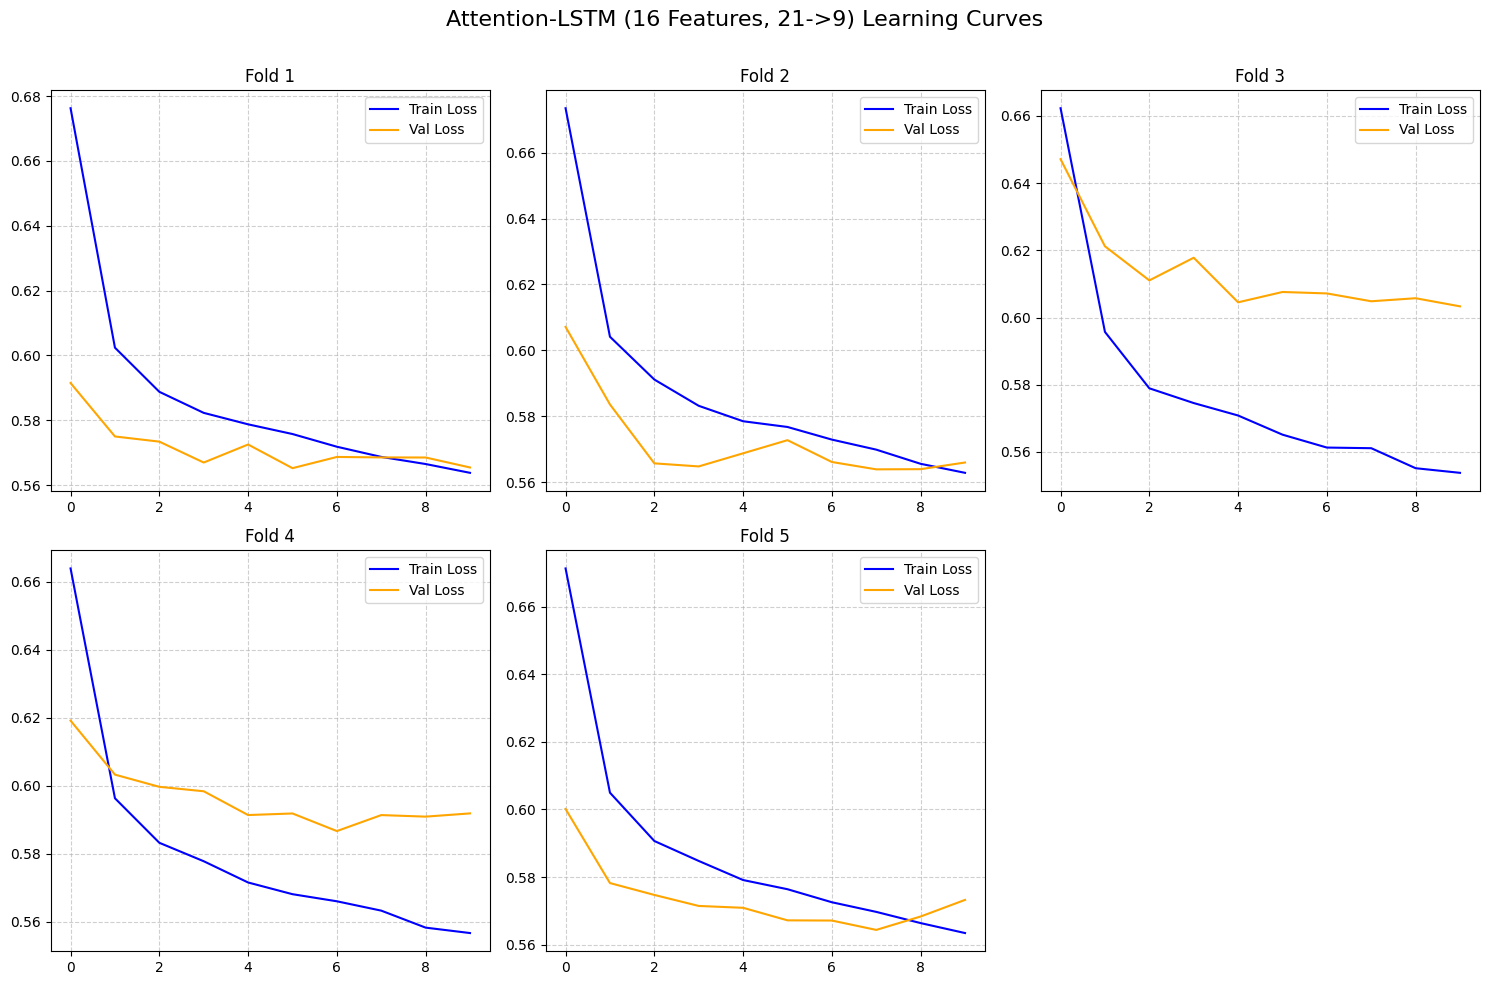


Training Master Attention-LSTM (16 Features)

FINAL METRICS:
MAE: 0.5874
R²:  0.3527


In [ ]:
print(" ATTENTION-LSTM: PREDICTING ALL 16 FEATURES (21 -> 9)")

# MODEL BUILDER (Reversed)
def build_attention_lstm_16_rev():
    inputs = Input(shape=(OBS_21, num_features_in))
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    attention_out = Attention()([lstm_out, lstm_out])
    attention_out = Dropout(0.3)(attention_out)
    lstm_out_2 = LSTM(64, return_sequences=False)(attention_out)
    dense_1 = Dense(64, activation='relu')(lstm_out_2)

    outputs = Dense(PRED_9 * num_target_features_16)(dense_1)
    outputs = Reshape((PRED_9, num_target_features_16))(outputs)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mae')
    return model

# 5-FOLD CROSS VALIDATION
print("\nStarting 5-Fold Cross Validation")
cv_mae_att_16_rev = []
all_histories_att_16_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_16_rev[train_idx], y_train_16_rev[val_idx]

    model_cv = build_attention_lstm_16_rev()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=150, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_att_16_rev.append(fold_loss)
    all_histories_att_16_rev.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Attention-LSTM (16 Features, 21->9) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_att_16_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MODEL TRAINING
print("\nTraining Master Attention-LSTM (16 Features)")
master_att_16_rev = build_attention_lstm_16_rev()
master_att_16_rev.fit(X_train_3d_rev, y_train_16_rev, epochs=150, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_att_16_rev = master_att_16_rev.predict(X_test_3d_rev, verbose=0)
y_test_16_flat_rev = y_test_16_rev.reshape(y_test_16_rev.shape[0], -1)
y_pred_att_16_flat_rev = y_pred_att_16_rev.reshape(y_pred_att_16_rev.shape[0], -1)

mae_att_16_rev = mean_absolute_error(y_test_16_flat_rev, y_pred_att_16_flat_rev)
r2_att_16_rev = r2_score(y_test_16_flat_rev, y_pred_att_16_flat_rev)

print(f"\nFINAL METRICS:")
print(f"MAE: {mae_att_16_rev:.4f}")
print(f"R²:  {r2_att_16_rev:.4f}")

<h2>Attention LSTM Predicting 8 Biomarkers (21 to 9 Days)</h2>

 ATTENTION-LSTM: PREDICTING 8 BIOMARKERS (21 -> 9)

Starting 5-Fold Cross Validation
Fold 1 MAE: 0.4011
Fold 2 MAE: 0.4769
Fold 3 MAE: 0.4934
Fold 4 MAE: 0.4787
Fold 5 MAE: 0.4654


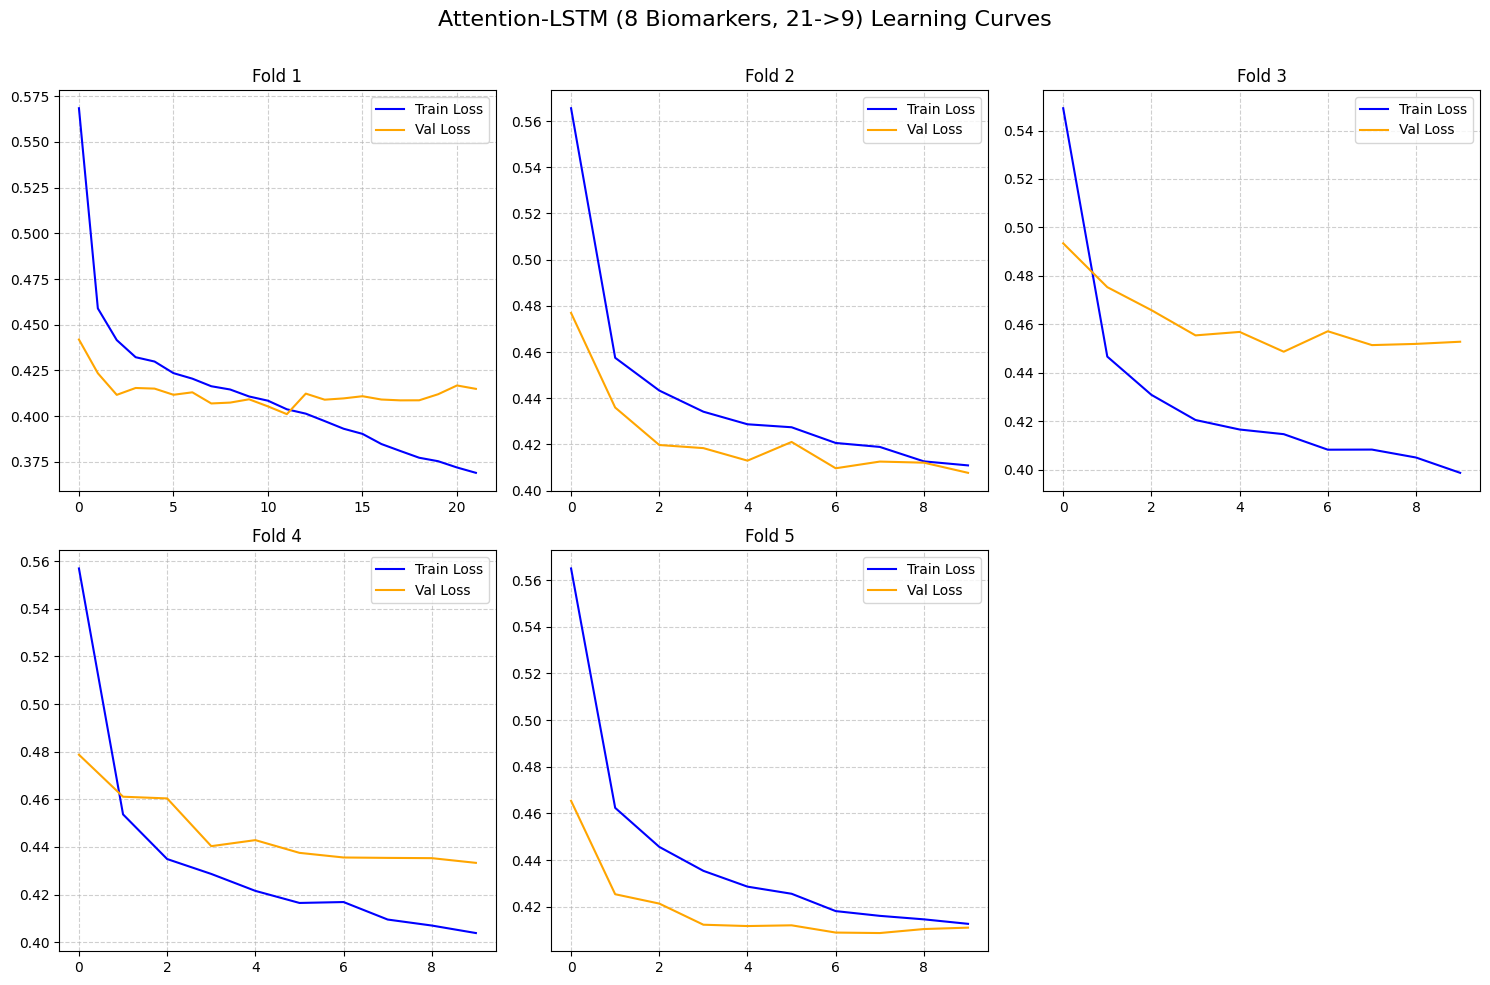


Training Master Attention-LSTM (8 Biomarkers)

FINAL METRICS:
MAE: 0.4458
R²:  0.5787


In [ ]:
print(" ATTENTION-LSTM: PREDICTING 8 BIOMARKERS (21 -> 9)")

# MODEL BUILDER
def build_attention_lstm_8_rev():
    inputs = Input(shape=(OBS_21, num_features_in))
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    attention_out = Attention()([lstm_out, lstm_out])
    attention_out = Dropout(0.3)(attention_out)
    lstm_out_2 = LSTM(64, return_sequences=False)(attention_out)
    dense_1 = Dense(64, activation='relu')(lstm_out_2)

    outputs = Dense(PRED_9 * num_target_features_8)(dense_1)
    outputs = Reshape((PRED_9, num_target_features_8))(outputs)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mae')
    return model

# 5-FOLD CROSS VALIDATION
print("\nStarting 5-Fold Cross Validation")
cv_mae_att_8_rev = []
all_histories_att_8_rev = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_train_3d_rev), 1):
    X_fold_train, X_fold_val = X_train_3d_rev[train_idx], X_train_3d_rev[val_idx]
    y_fold_train, y_fold_val = y_train_8_rev[train_idx], y_train_8_rev[val_idx]

    model_cv = build_attention_lstm_8_rev()
    history = model_cv.fit(X_fold_train, y_fold_train, validation_data=(X_fold_val, y_fold_val),
                           epochs=150, batch_size=16, callbacks=[early_stop], verbose=0)

    fold_loss = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_mae_att_8_rev.append(fold_loss)
    all_histories_att_8_rev.append(history.history)
    print(f"Fold {fold_no} MAE: {fold_loss:.4f}")

# PLOTTING
plt.figure(figsize=(15, 10))
plt.suptitle('Attention-LSTM (8 Biomarkers, 21->9) Learning Curves', fontsize=16)
for i, hist in enumerate(all_histories_att_8_rev):
    plt.subplot(2, 3, i+1)
    plt.plot(hist['loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'Fold {i+1}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# MODEL TRAINING
print("\nTraining Master Attention-LSTM (8 Biomarkers)")
master_att_8_rev = build_attention_lstm_8_rev()
master_att_8_rev.fit(X_train_3d_rev, y_train_8_rev, epochs=150, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=0)

y_pred_att_8_rev = master_att_8_rev.predict(X_test_3d_rev, verbose=0)
y_test_8_flat_rev = y_test_8_rev.reshape(y_test_8_rev.shape[0], -1)
y_pred_att_8_flat_rev = y_pred_att_8_rev.reshape(y_pred_att_8_rev.shape[0], -1)

mae_att_8_rev = mean_absolute_error(y_test_8_flat_rev, y_pred_att_8_flat_rev)
r2_att_8_rev = r2_score(y_test_8_flat_rev, y_pred_att_8_flat_rev)

print(f"\nFINAL METRICS:")
print(f"MAE: {mae_att_8_rev:.4f}")
print(f"R²:  {r2_att_8_rev:.4f}")

<h2>Hybrid CNN Classification using Attention-LSTM (21 to 9 Days)</h2>

In [ ]:
print(" CNN CLASSIFICATION: ATTENTION-LSTM HYBRID (21 -> 9)")

# Generating predictions for the training set to properly stitch the history
y_pred_train_att_16_rev = master_att_16_rev.predict(X_train_3d_rev, verbose=0)

# Stitching (21 Real + 9 Forecasted)
train_stitched_att_rev = np.concatenate([X_train_3d_rev, y_pred_train_att_16_rev], axis=1)
test_stitched_att_rev = np.concatenate([X_test_3d_rev, y_pred_att_16_rev], axis=1)

# Building CNN model
model_cnn_att_rev = tf.keras.models.Sequential([
    Input(shape=(total_days, total_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn_att_rev.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training and Evaluating
print("Training CNN on Attention-LSTM Hybrid Data")
model_cnn_att_rev.fit(train_stitched_att_rev, y_train_labels_rev, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

y_pred_probs_att_rev = model_cnn_att_rev.predict(test_stitched_att_rev, verbose=0)
y_pred_classes_att_rev = np.argmax(y_pred_probs_att_rev, axis=1)
hybrid_acc_att_rev = accuracy_score(y_test_labels_rev, y_pred_classes_att_rev)

print(f"\nAttention Hybrid Accuracy: {hybrid_acc_att_rev:.4f}")

print("\nDETAILED METRICS")
att_dict_rev = classification_report(y_test_labels_rev, y_pred_classes_att_rev, output_dict=True, zero_division=0)
att_df_rev = pd.DataFrame(att_dict_rev).transpose().drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
att_metrics_df_rev = att_df_rev[['precision', 'recall', 'f1-score']].round(4)
att_metrics_df_rev.index.name = 'Risk State'
att_metrics_df_rev.reset_index(inplace=True)
att_metrics_df_rev['Risk State'] = att_metrics_df_rev['Risk State'].replace(risk_mapping)
print(att_metrics_df_rev.to_string(index=False))

 CNN CLASSIFICATION: ATTENTION-LSTM HYBRID (21 -> 9)
Training CNN on Attention-LSTM Hybrid Data

Attention Hybrid Accuracy: 0.7617

DETAILED METRICS
Risk State  precision  recall  f1-score
       1.0     0.7250  0.4328    0.5421
       2.0     0.7800  0.9242    0.8460
       3.0     0.4118  0.2333    0.2979
       4.0     0.6667  0.1429    0.2353


<h2>R² Summary Table</h2>

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score

# Helper function to fetch R² scores
def safe_get_r2(metric_name, true_name, pred_name):
    if metric_name in globals():
        val = globals()[metric_name]
        if isinstance(val, (list, tuple, np.ndarray)):
            return round(val[0], 4)
        return round(val, 4)
    if true_name in globals() and pred_name in globals():
        return round(r2_score(globals()[true_name], globals()[pred_name]), 4)
    return "Not Run"

summary_data = {
    "Model Type": [
        "Random Forest", "Random Forest",
        "Standard LSTM", "Standard LSTM",
        "BiLSTM", "BiLSTM",
        "Attention LSTM", "Attention LSTM"
    ],
    "Features": [
        "16 (All)", "8 (Biomarkers)",
        "16 (All)", "8 (Biomarkers)",
        "16 (All)", "8 (Biomarkers)",
        "16 (All)", "8 (Biomarkers)"
    ],
    "Phase 1: 9 -> 21 Days (R²)": [
        safe_get_r2('r2_all', 'y_test_all', 'y_pred_all'),
        safe_get_r2('r2_bio', 'y_test_bio', 'y_pred_bio'),
        safe_get_r2('r2_std_16', 'y_test_flat', 'y_pred_16_flat'),
        safe_get_r2('r2_std_8', 'y_test_flat', 'y_pred_8_flat'),
        safe_get_r2('r2_bi_16', 'y_test_16_flat', 'y_pred_bi_16_flat'),
        safe_get_r2('r2_bi_8', 'y_test_8_flat', 'y_pred_bi_8_flat'),
        safe_get_r2('r2_att_16', 'y_test_16_flat', 'y_pred_att_16_flat'),
        safe_get_r2('r2_att_8', 'y_test_8_flat', 'y_pred_att_8_flat')
    ],
    "Phase 2: 21 -> 9 Days (R²)": [
        safe_get_r2('r2_all_rf_rev', 'y_test_all_rev', 'y_pred_all_rev'),
        safe_get_r2('r2_bio_rf_rev', 'y_test_bio_rev', 'y_pred_bio_rev'),
        safe_get_r2('r2_std_16_rev', 'y_test_16_flat_rev', 'y_pred_std_16_flat_rev'),
        safe_get_r2('r2_std_8_rev', 'y_test_8_flat_rev', 'y_pred_std_8_flat_rev'),
        safe_get_r2('r2_bi_16_rev', 'y_test_16_flat_rev', 'y_pred_bi_16_flat_rev'),
        safe_get_r2('r2_bi_8_rev', 'y_test_8_flat_rev', 'y_pred_bi_8_flat_rev'),
        safe_get_r2('r2_att_16_rev', 'y_test_16_flat_rev', 'y_pred_att_16_flat_rev'),
        safe_get_r2('r2_att_8_rev', 'y_test_8_flat_rev', 'y_pred_att_8_flat_rev')
    ]
}

master_summary_df = pd.DataFrame(summary_data)

print("R² SUMMARY TABLE")
print(master_summary_df.to_string(index=False))

R² SUMMARY TABLE
    Model Type       Features  Phase 1: 9 -> 21 Days (R²)  Phase 2: 21 -> 9 Days (R²)
 Random Forest       16 (All)                      0.2745                      0.3432
 Random Forest 8 (Biomarkers)                      0.4887                      0.5720
 Standard LSTM       16 (All)                      0.2055                      0.2602
 Standard LSTM 8 (Biomarkers)                      0.3928                      0.4708
        BiLSTM       16 (All)                      0.2261                      0.2877
        BiLSTM 8 (Biomarkers)                      0.4076                      0.5192
Attention LSTM       16 (All)                      0.2742                      0.3527
Attention LSTM 8 (Biomarkers)                      0.4929                      0.5787
